# Quantum Multiclass Classification

In [30]:
# !python -m pip install numpy pandas \
#     qiskit-aer qiskit-algorithms qiskit-machine-learning qiskit-ibm-runtime \
#     pylatexenc ucimlrepo \
#     xgboost catboost seaborn libsvm-official \
#     jinja2 \
#     scikit-optimize imbalanced-learn

```mermaid
flowchart TD
    A[("Dataset_TehHijau.csv")] --> B[Load data]
    B --> C[Pilih fitur<br/>12 sensor + Humidity + Celsius]
    B --> D[Target: Kategori]

    C --> E[X = features]
    D --> F[y = LabelEncoder]

    E --> G[PCA variance analysis<br/>threshold 95% → n_optimal = n_qubits]

    E --> SUB[Subsample stratified Q_N]
    F --> SUB
    SUB --> LOOP
    G --> LOOP

    subgraph LOOP["Loop tiap model kuantum (QSVC, QXGB, QCAT) + best params"]
        direction TB

        subgraph CV["StratifiedKFold 5-fold CV<br/>shuffle, random_state=42"]
            direction TB
            SPLIT{{"Split per fold<br/>train_idx / val_idx"}}
            SPLIT -->|X_train, y_train| P1[StandardScaler.fit_transform]
            SPLIT -->|X_val, y_val| P4

            P1 --> P2[PCA n_components=n_optimal]
            P2 --> RS[["SMOTEENN Sampling<br/>(train fold only)"]]
            RS --> QK[["Quantum kernel<br/>(mode pqk: proyeksi Pauli → RBF)"]]
            QK --> P3[Classifier.fit]

            P3 --> P4[predict + predict_proba<br/>pada X_val asli]
            P4 --> P5[Metrik per fold:<br/>Acc, F1, ROC-AUC, PR-AUC,<br/>Precision, Recall, Log-Loss]
        end

        CV --> SC[Skor = AUROC+PRAUC+Acc / 3]
        SC --> BEST[Simpan best_result + OOF preds]
        BEST --> CSV[(results/csv/best_param/*.csv)]
        BEST --> AB[all_best.append]
    end

    

    AB --> T[Tabel evaluasi akhir<br/>metrik mean±std]
    T --> O1[(eval_quantum_final_hpo.csv)]
    AB --> CM[Confusion Matrix OOF<br/>+ per-class metrics]
    CM --> O2[(confusion_matrix_quantum_hpo.png)]
    AB --> LC[Learning Curve<br/>acc / prec / rec / f1 / log-loss]
```

## Utility Function

In [31]:
import time
from pathlib import Path
from datetime import datetime

all_best = []  # collects best_result from every model
_iter_t0 = None

# Logger setup
log_dir = Path("./results/logs/qml/best_param")
log_dir.mkdir(parents=True, exist_ok=True)
Path("./results/images").mkdir(parents=True, exist_ok=True)
Path("./results/csv").mkdir(parents=True, exist_ok=True)

def config_slug():
  """Slug ringkas konfigurasi skenario (DROP_CLASSES + resampling) -> beda
  nama log & checkpoint antar-konfigurasi."""
  import re
  parts = []
  if DROP_CLASSES:
    parts.append("drop" + "".join(sorted(map(str, DROP_CLASSES))))
  if not CUSTOM_TARGETS:
    parts.append("noresample")
  else:
    t = CUSTOM_TARGETS if isinstance(CUSTOM_TARGETS, str) else \
        "-".join(f"{k}{v}" for k, v in sorted(CUSTOM_TARGETS.items()))
    parts.append(f"{t}_{OVER_METHOD}_{UNDER_METHOD}")
  mode = globals().get("Q_MODE")
  if mode:
    parts.append(str(mode))
  return re.sub(r"[^A-Za-z0-9._-]+", "-", "_".join(parts) if parts else "default")

_current_log_path = None

def setup_logger(name):
  """Panggil di awal tiap section. name contoh: 'qsvc', 'qxgb', 'qcat'."""
  global _current_log_path
  _current_log_path = log_dir / f"quantum_{name}_{config_slug()}_hpo.log"
  # truncate file kalau sudah ada, biar tiap run fresh
  _current_log_path.write_text("")
  log(f"📝 Log: {_current_log_path}")
  log(f"🕒 Started: {datetime.now().isoformat(timespec='seconds')}")

def log(msg=""):
  """Print ke console dan append ke file log section aktif."""
  print(msg)
  if _current_log_path is not None:
    with open(_current_log_path, "a", encoding="utf-8") as f:
      f.write(str(msg) + "\n")


In [32]:
import sys
import os
import pandas as pd
import warnings
from qiskit.transpiler import generate_preset_pass_manager
import sys
import importlib

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

cwd = os.path.abspath(os.getcwd())
project_root = cwd.split("quantum-multiclass-classification")[0] + "quantum-multiclass-classification"
print(f"Project root: {project_root}")

sys.path.append(os.path.abspath(project_root))

# Test import module
from utils.prepare_data import prepare_data

def reload_package(package_name):
    modules_to_reload = [
        name for name in sys.modules
        if name.startswith(package_name)
    ]

    for name in sorted(modules_to_reload, reverse=True):
        importlib.reload(sys.modules[name])

# Usage
reload_package("model")
reload_package("utils")

Project root: /home/ubuntu/Documents/quantum-gesang/quantum-multiclass-classification


## 1. Load & Split Dataset

In [33]:
dataset_path = os.path.join(project_root, "dataset", "Dataset_TehHijau.csv")
feature_cols = [
        "MQ3", 
        "TGS822", 
        "TGS2602", 
        "MQ5", 
        "MQ138", 
        "TGS2620", 
        "TGS813", 
        "TGS2600", 
        "TGS2611", 
        "TGS2603",
        "Humidity",
        "Celsius",
    ]
target_cols = "Kategori"

# ── ⚙️ Skenario Eksperimen ──────────────────────────────────
# DROP_CLASSES   : label kelas (nilai asli kolom target) yang dibuang sebelum split.
#                  Contoh ["B"] -> buang kelas B. [] = pakai semua kelas.
# CUSTOM_TARGETS : target jumlah per-kelas saat resample (dihitung per fold, train fold only):
#                  {} = tanpa resampling. nilai = int (jumlah absolut) ATAU nama kelas lain
#                  (samakan jumlahnya), mis. {"B": "C", "E": "C"}. Kelas tak disebut = dibiarkan.
#                  "auto-over"  = full oversampling (semua ke mayoritas);
#                  "auto-under" = full undersampling (semua ke minoritas).
# OVER_METHOD    : teknik oversampling -> 'smote' | 'borderline' | 'smoteenn' | 'smotetomek'
# UNDER_METHOD   : teknik undersampling -> 'random' (target eksak) | 'tomek' (cleaning)
DROP_CLASSES   = ['B']
CUSTOM_TARGETS = {'E': 'C'}  # contoh: resample kelas E jadi sebanyak kelas C
OVER_METHOD    = "smoteenn"
UNDER_METHOD   = "random"


### 1.1 Exploratory Data Analysis

In [34]:
import pandas as pd
data = pd.read_csv(dataset_path)
data.head(10)

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Chop_ID,Sampling_ID,Aroma,Taste,Color,Appearance,Dreg,Kategori,Standar Kualitas,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
0,90.0000,43.0000,46.0000,133.0000,97.0000,46.0000,552.0000,289.0000,546.0000,371.0000,46.4000,38.9000,TR612,TR612_1,2.9000,36,3.2000,2.8000,3.2000,D,Baik,89.7000,89.0000,90,0.4830,-0.8729,-1.2381,807.0000,41.9000,41,43,0.7379,0.1399,-0.9604,377.0000,46.8000,46,48,0.7888,0.3436,-1.1531,421.0000,132.5000,132,133.0000,0.5270,0.0000,-2.0000,1192.5000,96.1000,95,97,0.7379,-0.1399,-0.9604,865.0000,45.7000,45,47,0.6749,0.3657,-0.7055,411.0000,551.6000,550,553,0.8433,-0.3281,-0.3359,4964.5000,289.8000,289.0000,291,0.7888,0.3436,-1.1531,2609.0000,546.5000,545,548,0.8498,0.0000,-0.4852,4918.5000,370.2000,369,371,0.7888,-0.3436,-1.1531,3331.0000,46.4300,46.3000,46.5000,0.0675,-0.3657,-0.7055,417.9500,38.8100,38.7000,38.9000,0.0876,-0.1884,-1.5261,349.3000,2.9000,2.9000,2.9000,0.0000,26.1000,36,36,36,0,324,3.2000,3.2000,3.2000,0.0000,28.8000,2.8000,2.8000,2.8000,0.0000,25.2000,3.2000,3.2000,3.2000,0.0000,28.8000
1,90.0000,42.0000,47.0000,133.0000,96.0000,47.0000,551.0000,290.0000,547.0000,371.0000,46.5000,38.9000,TR612,TR612_1,2.9000,36,3.2000,2.8000,3.2000,D,Baik,89.7000,89.0000,90,0.4830,-0.8729,-1.2381,807.0000,41.9000,41,43,0.7379,0.1399,-0.9604,377.0000,46.8000,46,48,0.7888,0.3436,-1.1531,421.0000,132.5000,132,133.0000,0.5270,0.0000,-2.0000,1192.5000,96.1000,95,97,0.7379,-0.1399,-0.9604,865.0000,45.7000,45,47,0.6749,0.3657,-0.7055,411.0000,551.6000,550,553,0.8433,-0.3281,-0.3359,4964.5000,289.8000,289.0000,291,0.7888,0.3436,-1.1531,2609.0000,546.5000,545,548,0.8498,0.0000,-0.4852,4918.5000,370.2000,369,371,0.7888,-0.3436,-1.1531,3331.0000,46.4300,46.3000,46.5000,0.0675,-0.3657,-0.7055,417.9500,38.8100,38.7000,38.9000,0.0876,-0.1884,-1.5261,349.3000,2.9000,2.9000,2.9000,0.0000,26.1000,36,36,36,0,324,3.2000,3.2000,3.2000,0.0000,28.8000,2.8000,2.8000,2.8000,0.0000,25.2000,3.2000,3.2000,3.2000,0.0000,28.8000
2,89.0000,42.0000,47.0000,133.0000,97.0000,45.0000,553.0000,291.0000,547.0000,369.0000,46.4000,38.9000,TR612,TR612_1,2.9000,36,3.2000,2.8000,3.2000,D,Baik,89.7000,89.0000,90,0.4830,-0.8729,-1.2381,807.0000,41.9000,41,43,0.7379,0.1399,-0.9604,377.0000,46.8000,46,48,0.7888,0.3436,-1.1531,421.0000,132.5000,132,133.0000,0.5270,0.0000,-2.0000,1192.5000,96.1000,95,97,0.7379,-0.1399,-0.9604,865.0000,45.7000,45,47,0.6749,0.3657,-0.7055,411.0000,551.6000,550,553,0.8433,-0.3281,-0.3359,4964.5000,289.8000,289.0000,291,0.7888,0.3436,-1.1531,2609.0000,546.5000,545,548,0.8498,0.0000,-0.4852,4918.5000,370.2000,369,371,0.7888,-0.3436,-1.1531,3331.0000,46.4300,46.3000,46.5000,0.0675,-0.3657,-0.7055,417.9500,38.8100,38.700

In [35]:
data.describe()

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Aroma,Taste,Color,Appearance,Dreg,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
count,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000,10409.0000
mean,89.4148,47.6007,47.9362,98.2916,89.1822,51.5488,533.6701,213.7386,531.1246,330.5003,48.3877,39.6567,2.9351,34.8889,3.0354,3.1353,3.0719,89.4012,88.0726,90.8381,0.9831,0.0311,-0.4979,797.2830,51.3814,46.4283,86.3774,12.7680,0.0479,-0.7677,461.0916,48.9235,46.6657,56.4011,3.4174,0.0421,-0.7428,435.5016,98.3196,97.1902,99.9750,0.9774,0.1539,-0.3362,872.0037,89.1671,87.8391,90.5666,0.9752,0.0541,-0.7782,790.1031,52.0472,50.2007,56.9313,2.4119,0.0111,-0.7795,460.3774,533.5854,530.4756,535.6482,1.7161,-0.2305,-0.6140,4754.9384,215.5427,212.0394,231.5642,6.5498,-0.0593,-0.6575,1919.9904,531.0398,529.3107,532.0894,1.0005,-0.0311,-0.8901,4742.8424,330.4472,328.8314,331.6405,0.9806,0.0223,-0.7770,2953.2800,4077.8091,48.1753,40342.7838,12742.2929,-0.0207,-0.4484,40727.0018,39.6562,39.5960,39.7184,0.0507,-0.0031,0.0236,355.6654,2.9351,2.9351,2.9351,0.0000,26.4163,34.8889,34.8889,34.8889,0.0000,314.0005,3.0354,3.0354,3.0354,0.0000,27.3184,3.1353,3.1353,3.1353,0.0000,28.2178,3.0719,3.0719,3.0719,0.0000,27.6469
std,3.6692,4.6781,4.6166,15.8494,4.2090,4.9676,7.0074,24.6137,5.5522,12.9071,3.1265,1.3128,0.2578,1.7327,0.2553,0.2705,0.3078,4.2821,7.6516,21.2644,7.0327,0.8407,1.5014,52.9311,134.

Text(0.5, 1.0, 'Histogram for the Kategori')

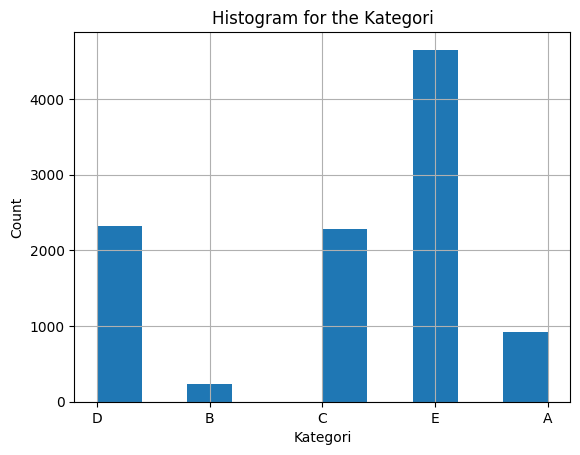

In [36]:
import matplotlib.pyplot as plt
data['Kategori'].hist()
plt.xlabel('Kategori')
plt.ylabel('Count')
plt.title('Histogram for the Kategori')

### 1.2 Split Data

In [37]:
# ⚙️ Skenario: drop kelas sesuai DROP_CLASSES (lihat config di Bagian 1)
if DROP_CLASSES:
    _before = len(data)
    data = data[~data[target_cols].isin(DROP_CLASSES)].reset_index(drop=True)
    print(f"🗑️  Drop kelas {DROP_CLASSES}: {_before} → {len(data)} baris")
print("Distribusi kelas:", dict(data[target_cols].value_counts().sort_index()))

X = data[feature_cols]
y = data[target_cols]

print(X.shape, y.shape)

🗑️  Drop kelas ['B']: 10409 → 10180 baris
Distribusi kelas: {'A': np.int64(927), 'C': np.int64(2287), 'D': np.int64(2317), 'E': np.int64(4649)}
(10180, 12) (10180,)


### 1.3 Encode Categorical Data (y = Kategori)

In [38]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

### 1.4 PCA Variance Analysis (threshold = 0.95)

In [39]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
def plot_pca_variance(X, n_components, threshold=0.95):
  pca = PCA(n_components=n_components)
  pca.fit(X)

  cumvar = np.cumsum(pca.explained_variance_ratio_)
  n_optimal = np.argmax(cumvar >= threshold) + 1

  plt.figure(figsize=(8, 5))
  plt.plot(range(1, n_components + 1), cumvar, marker='o', color='blue')
  plt.axhline(y=threshold, color='gray', linestyle='--', linewidth=1)
  plt.xlabel('Number of Principal Components')
  plt.ylabel('Cumulative Explained Variance')
  plt.xticks(range(1, n_components + 1))
  plt.grid(True)
  plt.tight_layout()
  plt.show()

  print(f'Optimal number of components to retain {threshold*100:.0f}% variance: {n_optimal}')

  return n_optimal

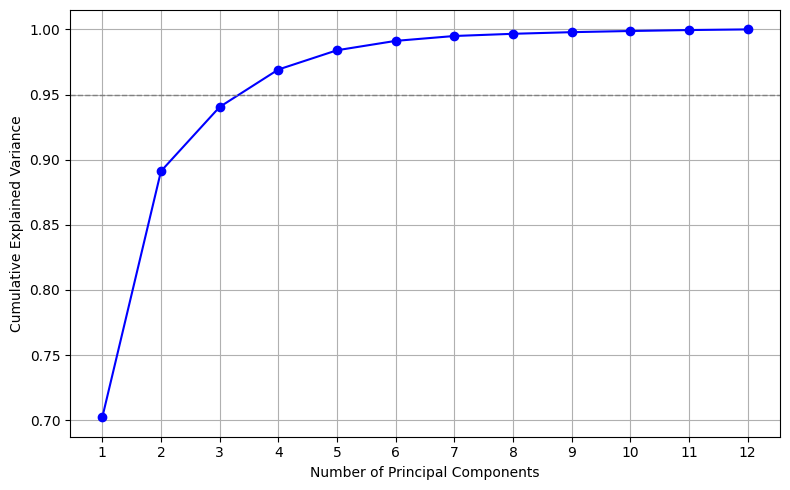

Optimal number of components to retain 95% variance: 4


In [40]:
n_optimal = plot_pca_variance(X, n_components=X.shape[1], threshold=0.95)

### 1.5 Komposisi Dataset (Sebelum vs Sesudah SMOTEENN)

Data di-oversampling pakai SMOTE dulu, trus nanti kan pasti ada noise, itu dibersihin pake ENN. ENN ini konsepnya ngecek tetangga terdekat dari data sintesis maupun data asli itu banyak yg sama atau nggak, misal datanya kelass B. Tetangganya mayoritas kelas B atau tidak. Kalau minoritas berarti dibuang. Kalau mayoritas disimpan

Komposisi kelas (full data, ilustrasi):


,Sebelum,Sesudah,Δ
A,927,927,0
C,2287,2287,0
D,2317,2317,0
E,4649,2287,-2362
TOTAL,10180,7818,-2362


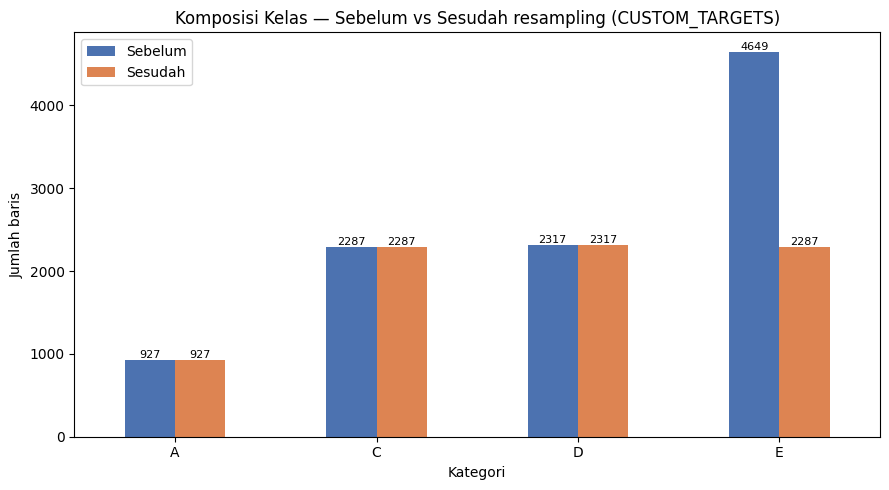

✅ Saved: ./results/images/composition_before_after_smoteenn.png


In [41]:
# ════════════════════════════════════════════════════════════
# 🔁 Komposisi kelas: SEBELUM vs SESUDAH SMOTEENN
# ════════════════════════════════════════════════════════════
# SMOTEENN diterapkan di ruang (StandardScaler → PCA), sama seperti di dalam CV.
# Di CV resampling hanya pada fold training; di sini full data dipakai semata
# sebagai ILUSTRASI efek resampling terhadap komposisi kelas.
from collections import Counter
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

class_names = list(label_encoder.classes_)

_Xp = PCA(n_components=n_optimal).fit_transform(StandardScaler().fit_transform(X))
if CUSTOM_TARGETS:
    from utils.imbalance_eval import make_custom_resampler
    _res = make_custom_resampler(CUSTOM_TARGETS, list(label_encoder.classes_),
                                 over_method=OVER_METHOD, under_method=UNDER_METHOD)
    _Xr, _yr = _res.fit_resample(_Xp, y)
else:
    _Xr, _yr = _Xp, y

_before, _after = Counter(y), Counter(_yr)
comp = pd.DataFrame({
    "Sebelum": [int(_before.get(i, 0)) for i in range(len(class_names))],
    "Sesudah": [int(_after.get(i, 0)) for i in range(len(class_names))],
}, index=class_names)
comp["Δ"] = comp["Sesudah"] - comp["Sebelum"]
comp.loc["TOTAL"] = comp.sum()
print("Komposisi kelas (full data, ilustrasi):")
display(comp)

ax = comp.drop(index="TOTAL")[["Sebelum", "Sesudah"]].plot(
    kind="bar", figsize=(9, 5), color=["#4C72B0", "#DD8452"])
ax.set_title("Komposisi Kelas — Sebelum vs Sesudah resampling (CUSTOM_TARGETS)")
ax.set_xlabel("Kategori"); ax.set_ylabel("Jumlah baris")
ax.tick_params(axis="x", rotation=0)
for c in ax.containers:
    ax.bar_label(c, fontsize=8)
plt.tight_layout()
import os
os.makedirs("./results/images", exist_ok=True)
os.makedirs("./results/csv", exist_ok=True)
plt.savefig("./results/images/composition_before_after_smoteenn.png", dpi=130, bbox_inches="tight")
plt.show()
print("✅ Saved: ./results/images/composition_before_after_smoteenn.png")

In [42]:
# ════════════════════════════════════════════════════════════
# ⚛️  Konfigurasi evaluasi KUANTUM
# ════════════════════════════════════════════════════════════
# n_qubits = n_features = n_optimal (dimensi PCA). PQK: kuantum O(N), klasik O(N^2).
# Q_N = ukuran subsample stratified. Default full data (pilihan user) — LAMBAT untuk
# QSVC (O(N^2..3)) & QXGB/QCAT (kernel NxN dipakai sbg fitur). Turunkan utk iterasi cepat.
from sklearn.model_selection import StratifiedShuffleSplit

Q_MODE = "pqk"        # mode kernel: 'fsk' | 'fqk' | 'fqk-hardware' | 'pqk'
Q_N    = len(X)       # subsample utk eval kuantum. Mis. 800 utk lebih cepat.

if Q_N < len(X):
    _idx, _ = next(StratifiedShuffleSplit(
        n_splits=1, train_size=Q_N, random_state=42).split(X, y))
    X, y = X.iloc[_idx].reset_index(drop=True), y[_idx]

print(f"⚛️  Quantum eval → N={len(X)} | n_qubits=n_features={n_optimal} | mode={Q_MODE}")


⚛️  Quantum eval → N=10180 | n_qubits=n_features=4 | mode=pqk


## 2. Model Evaluation

### 2.0 Pipeline runner

In [43]:
# Satu fungsi untuk seluruh pipeline CV + logging + simpan CSV + collect best.
import os
import time
import numpy as np
import pandas as pd
from itertools import product
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline          # imblearn Pipeline: sampler aktif HANYA saat .fit
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from model.quantum.qsvc import QSVCWrapper
from model.quantum.qxgb import QXGB
from model.quantum.qcat import QCAT
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    average_precision_score, matthews_corrcoef,
    precision_score, recall_score, log_loss, classification_report,
    balanced_accuracy_score,
)


def make_resampler():
    """Resampler kustom per-kelas (CUSTOM_TARGETS) via utils.imbalance_eval.
    None bila CUSTOM_TARGETS kosong (tanpa resampling). Target dihitung per fold (no leak)."""
    if not CUSTOM_TARGETS:
        return None
    from utils.imbalance_eval import make_custom_resampler
    return make_custom_resampler(
        CUSTOM_TARGETS, list(label_encoder.classes_),
        over_method=OVER_METHOD, under_method=UNDER_METHOD)


def resampler_steps():
    """Step pipeline imblearn untuk resampler terpilih ([] bila 'none')."""
    r = make_resampler()
    return [("resampler", r)] if r is not None else []


def evaluate_cv(model_name, log_name, search_space, build_clf, csv_name,
               n_splits=5, state=42, results_dir="./results/csv/best_param/"):
    """Jalankan grid CV untuk satu model lalu rekam best config ke `all_best`.

    Pipeline per fold: StandardScaler -> PCA -> SMOTEENN (train fold) -> classifier.
    Imbalance ditangani SMOTEENN, jadi TIDAK ada class_weight/sample_weight balancing.

    Memakai global: X, y, n_optimal, all_best, log, setup_logger.
    Mengembalikan best_result (juga sudah di-append ke all_best).
    """
    setup_logger(log_name)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)
    classes = np.unique(y)
    _cls_names = [str(c) for c in label_encoder.classes_]

    param_keys = list(search_space.keys())
    param_vals = list(search_space.values())
    sizes = {k: len(v) for k, v in search_space.items()}
    total_configs = int(np.prod([len(v) for v in param_vals]))
    total_fits = total_configs * skf.get_n_splits()
    space_str = " × ".join(f"{sizes[k]} {k}" for k in sizes)

    log(f"\U0001f52c Search space: {space_str} =  {total_configs} configs × "
        f"{skf.get_n_splits()} folds = {total_fits} fits")
    log(f"   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3 | resampling: {OVER_METHOD if CUSTOM_TARGETS else 'none'} | targets={CUSTOM_TARGETS} (train fold only)")

    best_score = -np.inf
    best_result = None
    results = []

    for i, comb in enumerate(product(*param_vals)):
        params = dict(zip(param_keys, comb))
        tag = " | ".join(f"{k}={v}" for k, v in params.items())
        log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
        t0 = time.perf_counter()

        accs, f1s, rocs, pras, precs, recs, losses = [], [], [], [], [], [], []
        baccs, precws, recws, f1ws = [], [], [], []
        y_val_all, y_pred_all = [], []
        y_prob_all = []   # OOF probabilities -> kurva ROC/PR

        for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            model = Pipeline([
                ("scaler", StandardScaler()),
                ("pca", PCA(n_components=n_optimal)),
                *resampler_steps(),
                ("clf", build_clf(params)),
            ])
            model.fit(X_train, y_train)

            y_pred = np.ravel(model.predict(X_val))   # QCAT predict -> kolom 2D, di-ravel
            y_prob = model.predict_proba(X_val)
            # CatBoost & QCAT (MultiClassOneVsAll) proba belum tentu sum=1 -> normalisasi
            if "catboost" in model_name.lower() or "qcat" in model_name.lower():
                y_prob = y_prob / y_prob.sum(axis=1, keepdims=True)

            y_val_all.extend(y_val)
            y_pred_all.extend(y_pred)
            y_prob_all.append(np.asarray(y_prob))

            acc = accuracy_score(y_val, y_pred)
            f1 = f1_score(y_val, y_pred, average="macro")
            roc = roc_auc_score(y_val, y_prob, average="macro", multi_class="ovr")
            pra = average_precision_score(y_val, y_prob, average="macro")
            prec = precision_score(y_val, y_pred, average="macro", zero_division=0)
            rec = recall_score(y_val, y_pred, average="macro")
            ll = log_loss(y_val, y_prob, labels=classes)

            accs.append(acc); f1s.append(f1); rocs.append(roc)
            pras.append(pra); precs.append(prec); recs.append(rec); losses.append(ll)

            bacc  = balanced_accuracy_score(y_val, y_pred)
            precw = precision_score(y_val, y_pred, average="weighted", zero_division=0)
            recw  = recall_score(y_val, y_pred, average="weighted")
            f1w   = f1_score(y_val, y_pred, average="weighted")
            baccs.append(bacc); precws.append(precw); recws.append(recw); f1ws.append(f1w)

            log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | "
                f"F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f} | Loss={ll:.4f}")
            _rep_df = pd.DataFrame(classification_report(
                y_val, y_pred, labels=classes, target_names=_cls_names,
                zero_division=0, output_dict=True)).T
            _rep_df["support"] = _rep_df["support"].astype(int)
            _rep_df = _rep_df.round(4)
            print(f"    📋 Classification report F{fold}:")
            display(_rep_df)
            if _current_log_path is not None:
                with open(_current_log_path, "a", encoding="utf-8") as _f:
                    _f.write(f"    📋 Classification report F{fold}:\n")
                    _f.write(_rep_df.to_string() + "\n")

            results.append({
                "tag": tag, **params, "fold": fold,
                "accuracy": acc, "precision": prec, "recall": rec,
                "F1": f1, "auroc": roc, "prauc": pra, "loss": ll,
            })

        # Aggregate (mean ± std across folds)
        acc_mean, acc_std = np.mean(accs), np.std(accs)
        prec_mean, prec_std = np.mean(precs), np.std(precs)
        rec_mean, rec_std = np.mean(recs), np.std(recs)
        f1_mean, f1_std = np.mean(f1s), np.std(f1s)
        roc_mean, roc_std = np.mean(rocs), np.std(rocs)
        pra_mean, pra_std = np.mean(pras), np.std(pras)
        loss_mean, loss_std = np.mean(losses), np.std(losses)
        mcc = matthews_corrcoef(y_val_all, y_pred_all)
        bacc_mean, bacc_std = np.mean(baccs), np.std(baccs)
        precw_mean, precw_std = np.mean(precws), np.std(precws)
        recw_mean, recw_std = np.mean(recws), np.std(recws)
        f1w_mean, f1w_std = np.mean(f1ws), np.std(f1ws)

        composite = (roc_mean + pra_mean + acc_mean) / 3

        log(
            f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
            f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
            f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
            f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
            f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
            f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
            f"Loss:{loss_mean:.4f}±{loss_std:.4f} | "
            f"MCC:{mcc:.4f} | "
            f"Composite:{composite:.4f}"
        )

        iter_time = time.perf_counter() - t0
        if composite > best_score:
            best_score = composite
            best_result = {
                "tag": tag,
                "composite": composite,
                "acc": f"{acc_mean:.4f}±{acc_std:.4f}",
                "prec": f"{prec_mean:.4f}±{prec_std:.4f}",
                "rec": f"{rec_mean:.4f}±{rec_std:.4f}",
                "f1": f"{f1_mean:.4f}±{f1_std:.4f}",
                "roc": f"{roc_mean:.4f}±{roc_std:.4f}",
                "pra": f"{pra_mean:.4f}±{pra_std:.4f}",
                "loss": f"{loss_mean:.4f}±{loss_std:.4f}",
                "mcc": f"{mcc:.4f}",
                "bal_acc": f"{bacc_mean:.4f}±{bacc_std:.4f}",
                "prec_w": f"{precw_mean:.4f}±{precw_std:.4f}",
                "rec_w": f"{recw_mean:.4f}±{recw_std:.4f}",
                "f1_w": f"{f1w_mean:.4f}±{f1w_std:.4f}",
                "params": params,
                "execution_time": iter_time,
                # OOF preds best config -> dipakai confusion matrix & per-class metrics
                "y_true": list(y_val_all),
                "y_pred": list(y_pred_all),
                "y_prob": np.vstack(y_prob_all),
            }

    log(f"\n\U0001f3c6 Best config : {best_result['tag']}")
    log(
        f"   Composite   : {best_result['composite']:.4f} "
        f"(AUROC={best_result['roc']} | "
        f"PRAUC={best_result['pra']} | "
        f"Acc={best_result['acc']} |"
        f"Prec={best_result['prec']} |"
        f"Rec={best_result['rec']} |"
        f"Loss={best_result['loss']})"
    )

    # -- Simpan hasil per-fold --
    os.makedirs(results_dir, exist_ok=True)
    filename = os.path.join(results_dir, csv_name)
    pd.DataFrame(results).to_csv(filename, index=False)
    log(f"✅ Saved: {filename}")

    # -- Collect best result --
    best_result["model"] = model_name
    # -- Per-class metrics (OOF, best config) via classification_report --
    _cls_names = [str(c) for c in label_encoder.classes_]
    best_result["report_text"] = classification_report(
        best_result["y_true"], best_result["y_pred"],
        labels=classes, target_names=_cls_names, zero_division=0)
    best_result["report_dict"] = classification_report(
        best_result["y_true"], best_result["y_pred"],
        labels=classes, target_names=_cls_names, output_dict=True, zero_division=0)
    log("")
    log("=" * 60)
    log(f"📋 Classification report (OOF, best config) — {model_name}:")
    log("=" * 60)
    log(best_result["report_text"])
    all_best.append(dict(best_result))
    log(f"✅ [{model_name}] recorded | Exec. time: {best_result['execution_time']:.1f}s")

    return best_result


def build_eval_table(all_best):
    """Tabel evaluasi: row = model, column = metrik (mean±std)."""
    rows = []
    for r in all_best:
        params_str = ' | '.join(f'{k}={v}' for k, v in r.get('params', {}).items())
        rows.append({
            'Model'          : r['model'],
            'Accuracy'       : r['acc'],
            'Precision'      : r['prec'],
            'Recall'         : r['rec'],
            'F1-Score'       : r['f1'],
            'ROC-AUC'        : r['roc'],
            'PR-AUC'         : r['pra'],
            'Log-Loss'       : r.get('loss', 'N/A'),
            'MCC'            : r.get('mcc', 'N/A'),
            'Exec. Time (s)' : round(r['execution_time'], 2) if 'execution_time' in r else 'N/A',
            'Best Params'    : params_str,
        })
    df = pd.DataFrame(rows)
    df = df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
    df.index += 1
    return df


# ── Factory: rekonstruksi pipeline kuantum dari (model_name, best_params) ─────
# Pipeline identik dengan evaluate_cv (Scaler → PCA → SMOTEENN → clf) supaya
# learning curve mencerminkan training yang sebenarnya. n_qubits=n_features=n_optimal.
# CATATAN: QXGB/QCAT sudah meng-hardcode objective/tree_method & loss_function di
# _build_model, jadi JANGAN dikirim ulang lewat params (akan TypeError duplikat).
def make_quantum(model_name, params):
    base = [
        ("scaler", StandardScaler()),
        ("pca",    PCA(n_components=n_optimal)),
        *resampler_steps(),
    ]
    qkw = dict(n_qubits=n_optimal, n_features=n_optimal, mode=Q_MODE)
    if   model_name.startswith("QSVC"):
        clf = QSVCWrapper(**qkw, **params)
    elif model_name.startswith("QXGB"):
        clf = QXGB(random_state=42, **qkw, **params)
    elif model_name.startswith("QCAT"):
        clf = QCAT(random_seed=42, **qkw, **params)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")
    base.append(("clf", clf))
    return Pipeline(base)


### 2.0.1 Checkpoint (resume lintas restart kernel)

Eval kuantum di full data lambat. `all_best` disimpan ke disk setiap satu model selesai, dan dimuat ulang saat rerun — model yang sudah kelar otomatis **dilewati**. Set `RESET_CHECKPOINT = True` lalu jalankan sel ini untuk mulai dari nol.

In [44]:
# ════════════════════════════════════════════════════════════
# 💾 Checkpoint — resume eval kuantum lintas restart kernel
# ════════════════════════════════════════════════════════════
# Hasil tiap model (all_best) disimpan ke disk setelah selesai, dan dimuat ulang
# saat rerun. evaluate_cv dibungkus agar:
#   - model yang sudah ada di checkpoint -> DILEWATI (pakai hasil tersimpan)
#   - tiap model selesai -> checkpoint langsung ditulis (aman bila kernel mati)
import os
import pickle

CKPT_PATH        = f"./results/checkpoints/qml_all_best_{config_slug()}.pkl"
RESET_CHECKPOINT = False   # True = hapus checkpoint & mulai dari nol

os.makedirs(os.path.dirname(CKPT_PATH), exist_ok=True)


def save_checkpoint(obj, path=CKPT_PATH):
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print(f"💾 Checkpoint disimpan → {path} ({len(obj)} model)")


def load_checkpoint(path=CKPT_PATH):
    if os.path.exists(path):
        with open(path, "rb") as f:
            obj = pickle.load(f)
        print(f"♻️  Checkpoint dimuat ← {path} "
              f"({len(obj)} model: {[r['model'] for r in obj]})")
        return obj
    print("ℹ️  Belum ada checkpoint — mulai baru.")
    return []


if RESET_CHECKPOINT and os.path.exists(CKPT_PATH):
    os.remove(CKPT_PATH)
    print("🗑️  Checkpoint dihapus (RESET_CHECKPOINT=True)")

# Resume: muat hasil model yang sudah selesai ke all_best
all_best = load_checkpoint()

# Bungkus evaluate_cv (sekali saja) -> skip model selesai + autosave tiap selesai
if not getattr(evaluate_cv, "_ckpt_wrapped", False):
    _evaluate_cv_inner = evaluate_cv

    def evaluate_cv(model_name, *args, **kwargs):
        done = {r["model"] for r in all_best}
        if model_name in done:
            print(f"⏭️  [{model_name}] sudah ada di checkpoint — dilewati "
                  f"(set RESET_CHECKPOINT=True utk ulang).")
            return next(r for r in all_best if r["model"] == model_name)
        res = _evaluate_cv_inner(model_name, *args, **kwargs)
        save_checkpoint(all_best)
        return res

    evaluate_cv._ckpt_wrapped = True

print(f"✅ Checkpoint siap. Model selesai: {[r['model'] for r in all_best]}")


♻️  Checkpoint dimuat ← ./results/checkpoints/qml_all_best_dropB_EC_smoteenn_random_pqk.pkl (3 model: ['QSVC - Circular', 'QSVC - Full', 'QSVC - Linear'])
✅ Checkpoint siap. Model selesai: ['QSVC - Circular', 'QSVC - Full', 'QSVC - Linear']


### 2.1 QSVC — Quantum Kernel SVC

SVC dengan kernel kuantum (`QSVCWrapper`). Mode `pqk` → kernel RBF di ruang ekspektasi Pauli; `gamma` = bandwidth-nya. Catatan: wrapper meng-hardcode `class_weight='balanced'`, jadi imbalance di-handle ganda dengan SMOTEENN — pilih salah satu bila ingin bersih.

In [45]:
search_space = {
    "kernel": ["circular"],      # feature map: full | linear | circular | pauli_z | ...
    "lambda_": [0.1],        # skala entanglement IQP
    "gamma": [1],          # bandwidth RBF (dipakai mode pqk)
    "C": [1],              # regularisasi SVC
    'm_landmarks': [50] if Q_MODE == 'fsk' or Q_MODE == 'fqk' else [None],     # jumlah landmark (mode fqk)
    'n_measurements': [1024] if Q_MODE == 'fsk' or Q_MODE == 'fqk' else [None],
}
evaluate_cv(
    model_name="QSVC - Circular",
    log_name="qsvc_circular",
    search_space=search_space,
    build_clf=lambda p: QSVCWrapper(
        n_qubits=n_optimal, n_features=n_optimal, mode=Q_MODE, **p),
    csv_name="qsvc_hpo.csv",
);

⏭️  [QSVC - Circular] sudah ada di checkpoint — dilewati (set RESET_CHECKPOINT=True utk ulang).


In [46]:
search_space = {
    "kernel": ["full"],      # feature map: full | linear | circular | pauli_z | ...
    "lambda_": [0.1],        # skala entanglement IQP
    "gamma": [1],          # bandwidth RBF (dipakai mode pqk)
    "C": [1],              # regularisasi SVC
    'm_landmarks': [50] if Q_MODE == 'fsk' or Q_MODE == 'fqk' else [None],     # jumlah landmark (mode fqk)
    'n_measurements': [1024] if Q_MODE == 'fsk' or Q_MODE == 'fqk' else [None],
}
evaluate_cv(
    model_name="QSVC - Full",
    log_name="qsvc_full",
    search_space=search_space,
    build_clf=lambda p: QSVCWrapper(
        n_qubits=n_optimal, n_features=n_optimal, mode=Q_MODE, **p),
    csv_name="qsvc_hpo.csv",
);

⏭️  [QSVC - Full] sudah ada di checkpoint — dilewati (set RESET_CHECKPOINT=True utk ulang).


In [47]:
search_space = {
    "kernel": ["linear"],      # feature map: full | linear | circular | pauli_z | ...
    "lambda_": [0.1],        # skala entanglement IQP
    "gamma": [1],          # bandwidth RBF (dipakai mode pqk)
    "C": [1],              # regularisasi SVC
    'm_landmarks': [50] if Q_MODE == 'fsk' or Q_MODE == 'fqk' else [None],     # jumlah landmark (mode fqk)
    'n_measurements': [1024] if Q_MODE == 'fsk' or Q_MODE == 'fqk' else [None],
}
evaluate_cv(
    model_name="QSVC - Linear",
    log_name="qsvc_linear",
    search_space=search_space,
    build_clf=lambda p: QSVCWrapper(
        n_qubits=n_optimal, n_features=n_optimal, mode=Q_MODE, **p),
    csv_name="qsvc_hpo.csv",
);

⏭️  [QSVC - Linear] sudah ada di checkpoint — dilewati (set RESET_CHECKPOINT=True utk ulang).


### 2.2 QXGB — Quantum Kernel + XGBoost

XGBoost yang dilatih di atas matriks kernel kuantum (`K_train` NxN dipakai sebagai fitur). `objective`/`tree_method` sudah di-set di `_build_model`, jadi cukup atur hiperparameter pohon.

In [48]:
search_space = {
    "kernel": ["full"],
    "lambda_": [1.0],
    "gamma": [1.0],
    "n_estimators": [150],
    "learning_rate": [0.1],
    "max_depth": [4],
    "min_child_weight": [1],
    "reg_lambda": [1.0],
}
evaluate_cv(
    model_name="QXGB - Full",
    log_name="qxgb_full",
    search_space=search_space,
    build_clf=lambda p: QXGB(
        n_qubits=n_optimal, n_features=n_optimal, mode=Q_MODE,
        random_state=42, **p),
    csv_name="qxgb_hpo.csv",
);

search_space = {
    "kernel": ["linear"],
    "lambda_": [1.0],
    "gamma": [1.0],
    "n_estimators": [150],
    "max_depth": [4],
    "learning_rate": [0.1],
    "min_child_weight": [1],
    "reg_lambda": [1.0],
}
evaluate_cv(
    model_name="QXGB - Linear",
    log_name="qxgb_linear",
    search_space=search_space,
    build_clf=lambda p: QXGB(
        n_qubits=n_optimal, n_features=n_optimal, mode=Q_MODE,
        random_state=42, **p),
    csv_name="qxgb_hpo.csv",
);

search_space = {
    "kernel": ["circular"],
    "lambda_": [1.0],
    "gamma": [1.0],
    "n_estimators": [150],
    "max_depth": [4],
    "learning_rate": [0.1],
    "min_child_weight": [1],
    "reg_lambda": [1.0],
}
evaluate_cv(
    model_name="QXGB - Circular",
    log_name="qxgb_circular",
    search_space=search_space,
    build_clf=lambda p: QXGB(
        n_qubits=n_optimal, n_features=n_optimal, mode=Q_MODE,
        random_state=42, **p),
    csv_name="qxgb_hpo.csv",
);

📝 Log: results/logs/qml/best_param/quantum_qxgb_full_dropB_EC_smoteenn_random_pqk_hpo.log
🕒 Started: 2026-06-11T11:38:32
🔬 Search space: 1 kernel × 1 lambda_ × 1 gamma × 1 n_estimators × 1 learning_rate × 1 max_depth × 1 min_child_weight × 1 reg_lambda =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3 | resampling: smoteenn | targets={'E': 'C'} (train fold only)

  ▶ [1/1] kernel=full | lambda_=1.0 | gamma=1.0 | n_estimators=150 | learning_rate=0.1 | max_depth=4 | min_child_weight=1 | reg_lambda=1.0
    F1 → Acc=0.8453 | Prec=0.8267 | Rec=0.8454 | F1=0.8347 | AUROC=0.9679 | PRAUC=0.9194 | Loss=0.4550
    📋 Classification report F1:


,precision,recall,f1-score,support
A,0.7895,0.8108,0.8000,185
C,0.8375,0.8796,0.8581,457
D,0.7731,0.8664,0.8171,464
E,0.9066,0.8247,0.8637,930
accuracy,0.8453,0.8453,0.8453,0
macro avg,0.8267,0.8454,0.8347,2036
weighted avg,0.8500,0.8453,0.8460,2036


    F2 → Acc=0.8669 | Prec=0.8601 | Rec=0.8589 | F1=0.8579 | AUROC=0.9751 | PRAUC=0.9347 | Loss=0.4201
    📋 Classification report F2:


,precision,recall,f1-score,support
A,0.8802,0.7946,0.8352,185
C,0.8388,0.8993,0.8680,457
D,0.8043,0.8858,0.8431,464
E,0.9171,0.8559,0.8854,930
accuracy,0.8669,0.8669,0.8669,0
macro avg,0.8601,0.8589,0.8579,2036
weighted avg,0.8704,0.8669,0.8673,2036


    F3 → Acc=0.8551 | Prec=0.8502 | Rec=0.8562 | F1=0.8516 | AUROC=0.9714 | PRAUC=0.9333 | Loss=0.4267
    📋 Classification report F3:


...

    F4 → Acc=0.8880 | Prec=0.8783 | Rec=0.8939 | F1=0.8852 | AUROC=0.9829 | PRAUC=0.9544 | Loss=0.3297
    📋 Classification report F4:


,precision,recall,f1-score,support
A,0.8830,0.8925,0.8877,186
C,0.8734,0.9192,0.8957,458
D,0.8185,0.8963,0.8557,463
E,0.9383,0.8676,0.9016,929
accuracy,0.8880,0.8880,0.8880,0
macro avg,0.8783,0.8939,0.8852,2036
weighted avg,0.8914,0.8880,0.8886,2036


    F5 → Acc=0.8993 | Prec=0.8865 | Rec=0.9071 | F1=0.8960 | AUROC=0.9858 | PRAUC=0.9606 | Loss=0.3111
    📋 Classification report F5:


,precision,recall,f1-score,support
A,0.8673,0.9140,0.8901,186
C,0.8873,0.9300,0.9081,457
D,0.8502,0.9071,0.8777,463
E,0.9412,0.8774,0.9082,930
accuracy,0.8993,0.8993,0.8993,0
macro avg,0.8865,0.9071,0.8960,2036
weighted avg,0.9016,0.8993,0.8996,2036


  ✅  Acc:0.8937±0.0063 | Precision:0.8815±0.0071  |Recall:0.8985±0.0071 |F1:0.8891±0.0069 | AUROC:0.9843±0.0012 | PRAUC:0.9574±0.0029 | Loss:0.3254±0.0095 | MCC:0.8467 | Composite:0.9452

🏆 Best config : kernel=circular | lambda_=1.0 | gamma=1.0 | n_estimators=150 | max_depth=4 | learning_rate=0.1 | min_child_weight=1 | reg_lambda=1.0
   Composite   : 0.9452 (AUROC=0.9843±0.0012 | PRAUC=0.9574±0.0029 | Acc=0.8937±0.0063 |Prec=0.8815±0.0071 |Rec=0.8985±0.0071 |Loss=0.3254±0.0095)
✅ Saved: ./results/csv/best_param/qxgb_hpo.csv

📋 Classification report (OOF, best config) — QXGB - Circular:
              precision    recall  f1-score   support

           A       0.87      0.89      0.88       927
           C       0.87      0.93      0.90      2287
           D       0.84      0.90      0.87      2317
           E       0.94      0.87      0.91      4649

    accuracy                           0.89     10180
   macro avg       0.88      0.90      0.89     10180
weighted avg       0.90   

### 2.3 QCAT — Quantum Kernel + CatBoost

CatBoost (`MultiClassOneVsAll`) di atas matriks kernel kuantum. `predict` mengembalikan kolom 2D (sudah di-`ravel` di runner) dan proba dinormalisasi agar sum=1.

In [49]:
search_space = {
    "kernel": ["full"],
    "lambda_": [1.0],
    "gamma": [1.0],
    "iterations": [150],
    "depth": [4],
    "learning_rate": [0.1],
    "l2_leaf_reg": [1.0],
    "bagging_temperature": [0.5],
    "random_strength": [1],
}
evaluate_cv(
    model_name="QCAT - Full",
    log_name="qcat_full",
    search_space=search_space,
    build_clf=lambda p: QCAT(
        n_qubits=n_optimal, n_features=n_optimal, mode=Q_MODE,
        random_seed=42, **p),
    csv_name="qcat_hpo.csv",
);

search_space = {
    "kernel": ["linear"],
    "lambda_": [1.0],
    "gamma": [1.0],
    "iterations": [150],
    "depth": [4],
    "learning_rate": [0.1],
    "l2_leaf_reg": [1.0],
    "bagging_temperature": [0.5],
    "random_strength": [1],
}
evaluate_cv(
    model_name="QCAT - Linear",
    log_name="qcat_linear",
    search_space=search_space,
    build_clf=lambda p: QCAT(
        n_qubits=n_optimal, n_features=n_optimal, mode=Q_MODE,
        random_seed=42, **p),
    csv_name="qcat_hpo.csv",
);

search_space = {
    "kernel": ["circular"],
    "lambda_": [1.0],
    "gamma": [1.0],
    "iterations": [150],
    "depth": [4],
    "learning_rate": [0.1],
    "l2_leaf_reg": [1.0],
    "bagging_temperature": [0.5],
    "random_strength": [1],
}
evaluate_cv(
    model_name="QCAT - Circular",
    log_name="qcat_circular",
    search_space=search_space,
    build_clf=lambda p: QCAT(
        n_qubits=n_optimal, n_features=n_optimal, mode=Q_MODE,
        random_seed=42, **p),
    csv_name="qcat_hpo.csv",
);

📝 Log: results/logs/qml/best_param/quantum_qcat_full_dropB_EC_smoteenn_random_pqk_hpo.log
🕒 Started: 2026-06-11T11:43:52
🔬 Search space: 1 kernel × 1 lambda_ × 1 gamma × 1 iterations × 1 depth × 1 learning_rate × 1 l2_leaf_reg × 1 bagging_temperature × 1 random_strength =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3 | resampling: smoteenn | targets={'E': 'C'} (train fold only)

  ▶ [1/1] kernel=full | lambda_=1.0 | gamma=1.0 | iterations=150 | depth=4 | learning_rate=0.1 | l2_leaf_reg=1.0 | bagging_temperature=0.5 | random_strength=1
    F1 → Acc=0.7642 | Prec=0.7601 | Rec=0.7571 | F1=0.7532 | AUROC=0.9313 | PRAUC=0.8435 | Loss=0.7014
    📋 Classification report F1:


,precision,recall,f1-score,support
A,0.7961,0.6541,0.7181,185
C,0.7206,0.8578,0.7832,457
D,0.6765,0.7888,0.7284,464
E,0.8473,0.7280,0.7831,930
accuracy,0.7642,0.7642,0.7642,0
macro avg,0.7601,0.7571,0.7532,2036
weighted avg,0.7753,0.7642,0.7647,2036


    F2 → Acc=0.7854 | Prec=0.7874 | Rec=0.7723 | F1=0.7724 | AUROC=0.9422 | PRAUC=0.8634 | Loss=0.6659
    📋 Classification report F2:


,precision,recall,f1-score,support
A,0.8500,0.6432,0.7323,185
C,0.7412,0.8709,0.8008,457
D,0.6877,0.8211,0.7485,464
E,0.8708,0.7538,0.8081,930
accuracy,0.7854,0.7854,0.7854,0
macro avg,0.7874,0.7723,0.7724,2036
weighted avg,0.7981,0.7854,0.7860,2036


    F3 → Acc=0.7829 | Prec=0.7864 | Rec=0.7687 | F1=0.7699 | AUROC=0.9359 | PRAUC=0.8622 | Loss=0.6689
    📋 Classification report F3:


...

    F4 → Acc=0.8247 | Prec=0.8137 | Rec=0.8173 | F1=0.8125 | AUROC=0.9619 | PRAUC=0.9014 | Loss=0.5749
    📋 Classification report F4:


,precision,recall,f1-score,support
A,0.8204,0.7366,0.7762,186
C,0.8141,0.8799,0.8458,458
D,0.7164,0.8510,0.7779,463
E,0.9041,0.8019,0.8500,929
accuracy,0.8247,0.8247,0.8247,0
macro avg,0.8137,0.8173,0.8125,2036
weighted avg,0.8335,0.8247,0.8259,2036


    F5 → Acc=0.8502 | Prec=0.8391 | Rec=0.8438 | F1=0.8398 | AUROC=0.9679 | PRAUC=0.9158 | Loss=0.5550
    📋 Classification report F5:


,precision,recall,f1-score,support
A,0.8430,0.7796,0.8101,186
C,0.8191,0.9015,0.8583,457
D,0.7866,0.8596,0.8215,463
E,0.9076,0.8344,0.8695,930
accuracy,0.8502,0.8502,0.8502,0
macro avg,0.8391,0.8438,0.8398,2036
weighted avg,0.8543,0.8502,0.8506,2036


  ✅  Acc:0.8336±0.0091 | Precision:0.8194±0.0100  |Recall:0.8252±0.0099 |F1:0.8201±0.0103 | AUROC:0.9637±0.0030 | PRAUC:0.9059±0.0062 | Loss:0.5705±0.0131 | MCC:0.7609 | Composite:0.9011

🏆 Best config : kernel=circular | lambda_=1.0 | gamma=1.0 | iterations=150 | depth=4 | learning_rate=0.1 | l2_leaf_reg=1.0 | bagging_temperature=0.5 | random_strength=1
   Composite   : 0.9011 (AUROC=0.9637±0.0030 | PRAUC=0.9059±0.0062 | Acc=0.8336±0.0091 |Prec=0.8194±0.0100 |Rec=0.8252±0.0099 |Loss=0.5705±0.0131)
✅ Saved: ./results/csv/best_param/qcat_hpo.csv

📋 Classification report (OOF, best config) — QCAT - Circular:
              precision    recall  f1-score   support

           A       0.81      0.74      0.78       927
           C       0.81      0.89      0.85      2287
           D       0.75      0.85      0.80      2317
           E       0.90      0.81      0.86      4649

    accuracy                           0.83     10180
   macro avg       0.82      0.83      0.82     10180
weight

## 3. Final Evaluation

### 3.1 Tabel evaluasi akhir (row = model, column = metrik, mean ± std)

In [50]:
# ════════════════════════════════════════════════════════════
# 📊 TABEL EVALUASI AKHIR – Quantum Models
# Hijau = pemenang tiap metrik | Merah = posisi terakhir
# ════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd

pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.4f}'.format)

eval_df = build_eval_table(all_best)

# Arah "lebih baik": higher-better vs lower-better (Log-Loss & waktu = makin kecil makin baik).
_higher_better = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC', 'MCC']
_lower_better  = ['Log-Loss', 'Exec. Time (s)']

def _num(v):
    try:
        return float(str(v).split('±')[0])
    except (ValueError, TypeError):
        return np.nan

def _highlight_win_lose(col):
    """Hijau utk nilai terbaik, merah utk terburuk, per kolom metrik."""
    if col.name not in _higher_better + _lower_better:
        return [''] * len(col)
    vals = col.map(_num)
    if vals.notna().sum() == 0:
        return [''] * len(col)
    if col.name in _higher_better:
        win, lose = vals.max(), vals.min()
    else:
        win, lose = vals.min(), vals.max()
    styles = []
    for v in vals:
        if v == win:
            styles.append('background-color: #b6e7b0; color: #14532d; font-weight: bold')
        elif v == lose:
            styles.append('background-color: #f4b6b6; color: #7f1d1d')
        else:
            styles.append('')
    return styles

eval_styled = eval_df.style.apply(_highlight_win_lose, axis=0)
display(eval_styled)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Log-Loss,MCC,Exec. Time (s),Best Params
1,QSVC - Circular,0.9682±0.0036,0.9537±0.0049,0.9674±0.0044,0.9602±0.0045,0.9974±0.0007,0.9884±0.0032,0.0928±0.0117,0.9539,72.280000,kernel=circular | lambda_=0.1 | gamma=1 | C=1 | m_landmarks=None | n_measurements=None
2,QSVC - Full,0.9678±0.0042,0.9532±0.0056,0.9671±0.0047,0.9598±0.0050,0.9974±0.0007,0.9885±0.0030,0.0924±0.0118,0.9533,80.570000,kernel=full | lambda_=0.1 | gamma=1 | C=1 | m_landmarks=None | n_measurements=None
3,QSVC - Linear,0.9683±0.0038,0.9538±0.0050,0.9677±0.0046,0.9604±0.0046,0.9974±0.0007,0.9885±0.0031,0.0925±0.0116,0.9540,89.130000,kernel=linear | lambda_=0.1 | gamma=1 | C=1 | m_landmarks=None | n_measurements=None
4,QXGB - Linear,0.9106±0.0104,0.8964±0.0122,0.9137±0.0103,0.9041±0.0114,0.9881±0.0014,0.9650±0.0042,0.2898±0.0134,0.8712,105.000000,kernel=linear | lambda_=1.0 | gamma=1.0 | n_estimators=150 | max_depth=4 | learning_rate=0.1 | min_child_weight=1 | reg_lambda=1.0
5,QXGB - Circular,0.8937±0.0063,0.8815±0.0071,0.8985±0.0071,0.8891±0.0069,0.9843±0.0012,0.9574±0.0029,0.3254±0.0095,0.8467,104.840000,kernel=circular | lambda_=1.0 | gamma=1.0 | n_estimators=150 | max_depth=4 | learning_rate=0.1 | min_child_weight=1 | reg_lambda=1.0
6,QXGB - Full,0.8552±0.0098,0.8442±0.0142,0.8548±0.0063,0.8480±0.0100,0.9719±0.0030,0.9299±0.0066,0.4318±0.0140,0.7913,110.420000,kernel=full | lambda_=1.0 | gamma=1.0 | n_estimators=150 | learning_rate=0.1 | max_depth=4 | min_child_weight=1 | reg_lambda=1.0
7,QCAT - Linear,0.8426±0.0084,0.8264±0.0101,0.8384±0.0034,0.8300±0.0067,0.9696±0.0024,0.9158±0.0058,0.5419±0.0140,0.7747,338.550000,kernel=linear | lambda_=1.0 | gamma=1.0 | iterations=150 | depth=4 | learning_rate=0.1 | l2_leaf_reg=1.0 | bagging_temperature=0.5 | random_strength=1
8,QCAT - Circular,0.8336±0.0091,0.8194±0.0100,0.8252±0.0099,0.8201±0.0103,0.9637±0.0030,0.9059±0.0062,0.5705±0.0131,0.7609,339.340000,kernel=circular | lambda_=1.0 | gamma=1.0 | iterations=150 | depth=4 | learning_rate=0.1 | l2_leaf_reg=1.0 | bagging_temperature=0.5 | random_strength=1
9,QCAT - Full,0.7770±0.0091,0.7773±0.0122,0.7668±0.0053,0.7652±0.0076,0.9385±0.0052,0.8595±0.0088,0.6730±0.0154,0.6821,341.640000,kernel=full | lambda_=1.0 | gamma=1.0 | iterations=150 | depth=4 | learning_rate=0.1 | l2_leaf_reg=1.0 | bagging_temperature=0.5 | random_strength=1


### 3.2 Confusion matrix & per-class metrics (out-of-fold)

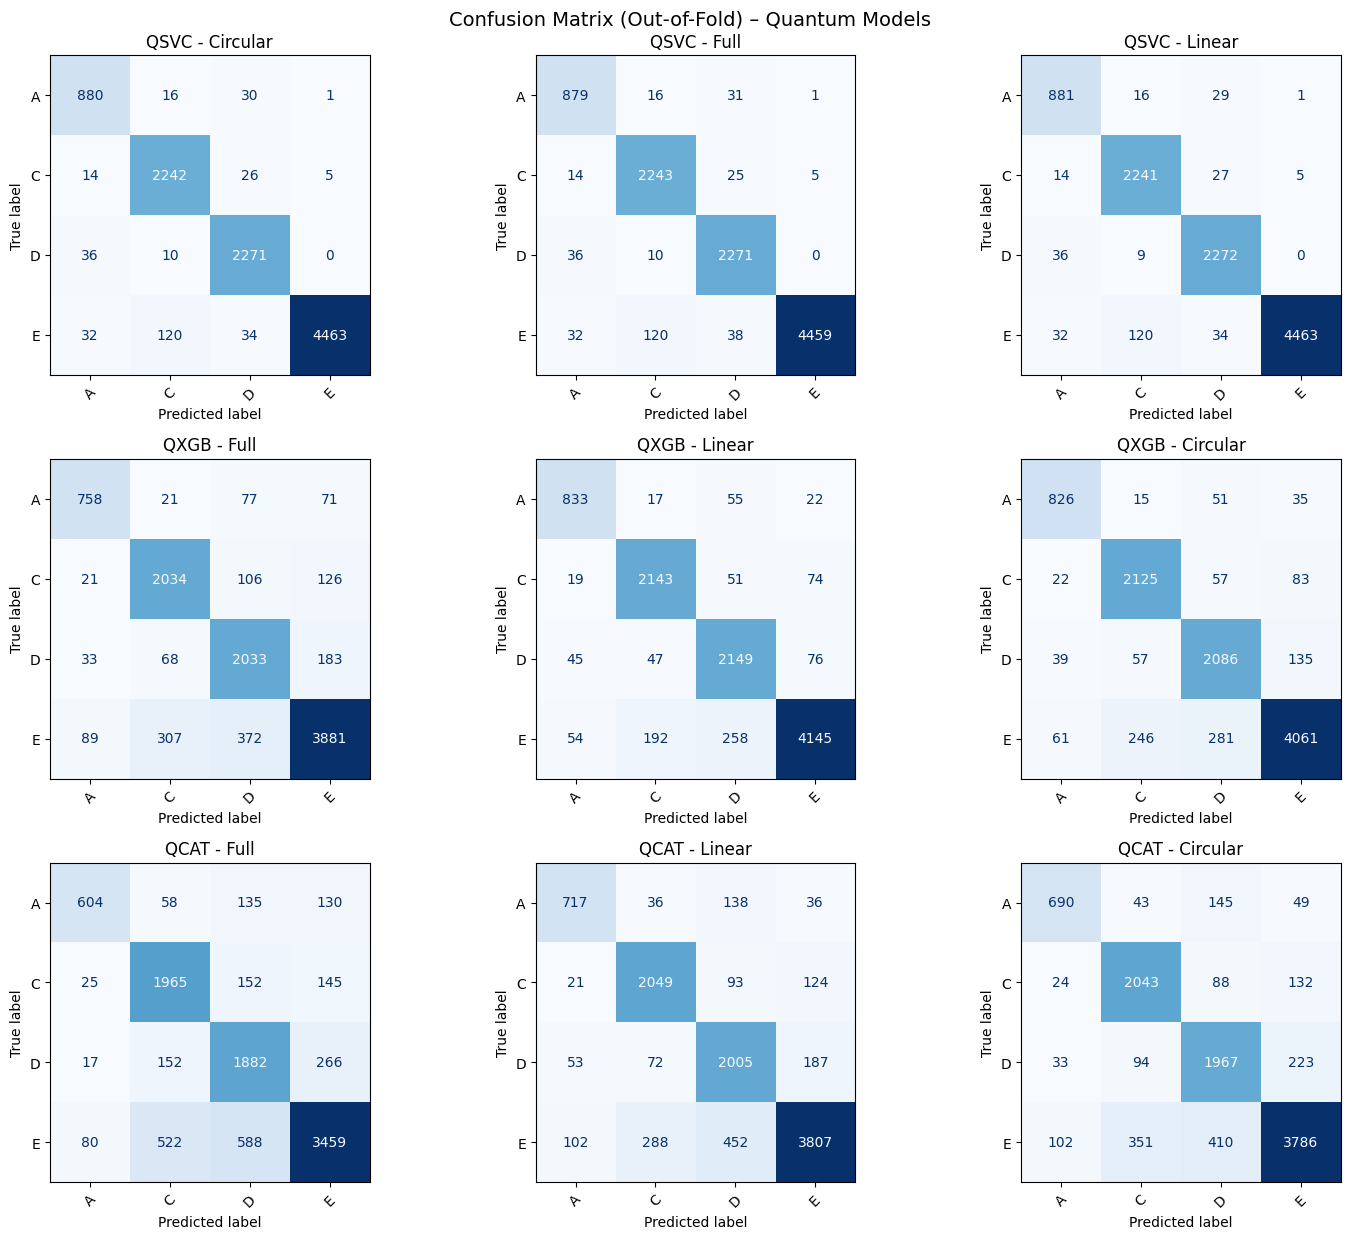

✅ Saved: ./results/images/confusion_matrix_quantum_hpo.png

QSVC - Circular — per-class metrics (OOF)
              precision    recall  f1-score   support

           A       0.91      0.95      0.93       927
           C       0.94      0.98      0.96      2287
           D       0.96      0.98      0.97      2317
           E       1.00      0.96      0.98      4649

    accuracy                           0.97     10180
   macro avg       0.95      0.97      0.96     10180
weighted avg       0.97      0.97      0.97     10180


QSVC - Full — per-class metrics (OOF)
              precision    recall  f1-score   support

           A       0.91      0.95      0.93       927
           C       0.94      0.98      0.96      2287
           D       0.96      0.98      0.97      2317
           E       1.00      0.96      0.98      4649

    accuracy                           0.97     10180
   macro avg       0.95      0.97      0.96     10180
weighted avg       0.97      0.97      0.97 

In [51]:
# ════════════════════════════════════════════════════════════
# 🔢 CONFUSION MATRIX + 📋 PER-CLASS METRICS – semua model (out-of-fold)
# ════════════════════════════════════════════════════════════
# Memakai prediksi out-of-fold (y_true/y_pred) yang dikumpulkan tiap model saat
# cross-validation → mencerminkan generalisasi, bukan performa di data training.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

class_names = list(label_encoder.classes_)
labels = np.arange(len(class_names))

models_cm = [r for r in all_best if "y_true" in r and "y_pred" in r]
if not models_cm:
    print("⚠️  Belum ada y_true/y_pred di all_best. Jalankan ulang sel-sel training dulu.")
else:
    # ── Confusion matrix grid ──
    n = len(models_cm)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.2 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, r in zip(axes, models_cm):
        cm = confusion_matrix(r["y_true"], r["y_pred"], labels=labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
        ax.set_title(r["model"])
        ax.tick_params(axis="x", rotation=45)

    for ax in axes[len(models_cm):]:
        ax.axis("off")

    fig.suptitle("Confusion Matrix (Out-of-Fold) – Quantum Models", fontsize=14)
    fig.tight_layout()

    os.makedirs("./results/images", exist_ok=True)
    os.makedirs("./results/csv", exist_ok=True)
    out_path = "./results/images/confusion_matrix_quantum_hpo.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {out_path}")

    # ── Per-class metrics: classification_report tiap model (OOF best config) ──
    # Pakai laporan yang sudah disimpan evaluate_cv; fallback hitung ulang bila perlu.
    for r in models_cm:
        print()
        print("=" * 60)
        print(f"{r['model']} — per-class metrics (OOF)")
        print("=" * 60)
        if r.get("report_text"):
            print(r["report_text"])
        else:
            print(classification_report(
                r["y_true"], r["y_pred"], labels=labels,
                target_names=class_names, zero_division=0))


### 3.3 Simpan tabel evaluasi

In [52]:
import os
os.makedirs('./results/images', exist_ok=True)
os.makedirs('./results/csv', exist_ok=True)
eval_df.to_csv('./results/csv/eval_quantum_final_hpo.csv', index=True)
print('✅ Saved: ./results/csv/eval_quantum_final_hpo.csv')

✅ Saved: ./results/csv/eval_quantum_final_hpo.csv


### 3.4 Learning curve (accuracy, precision, recall, f1, log-loss)

📊 Learning curve on N=10180 | CV=5 | sizes=[0.4 0.6 0.8 1. ]
  ⏭️  QSVC - Circular (cached)
  ⏭️  QSVC - Full (cached)
  ⏭️  QSVC - Linear (cached)
  ▶ QXGB - Full  ({'kernel': 'full', 'lambda_': 1.0, 'gamma': 1.0, 'n_estimators': 150, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 1, 'reg_lambda': 1.0}) ... done (checkpoint saved)
  ▶ QXGB - Linear  ({'kernel': 'linear', 'lambda_': 1.0, 'gamma': 1.0, 'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.1, 'min_child_weight': 1, 'reg_lambda': 1.0}) ... done (checkpoint saved)
  ▶ QXGB - Circular  ({'kernel': 'circular', 'lambda_': 1.0, 'gamma': 1.0, 'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.1, 'min_child_weight': 1, 'reg_lambda': 1.0}) ... done (checkpoint saved)
  ▶ QCAT - Full  ({'kernel': 'full', 'lambda_': 1.0, 'gamma': 1.0, 'iterations': 150, 'depth': 4, 'learning_rate': 0.1, 'l2_leaf_reg': 1.0, 'bagging_temperature': 0.5, 'random_strength': 1}) ... done (checkpoint saved)
  ▶ QCAT - Linear  ({'kernel':

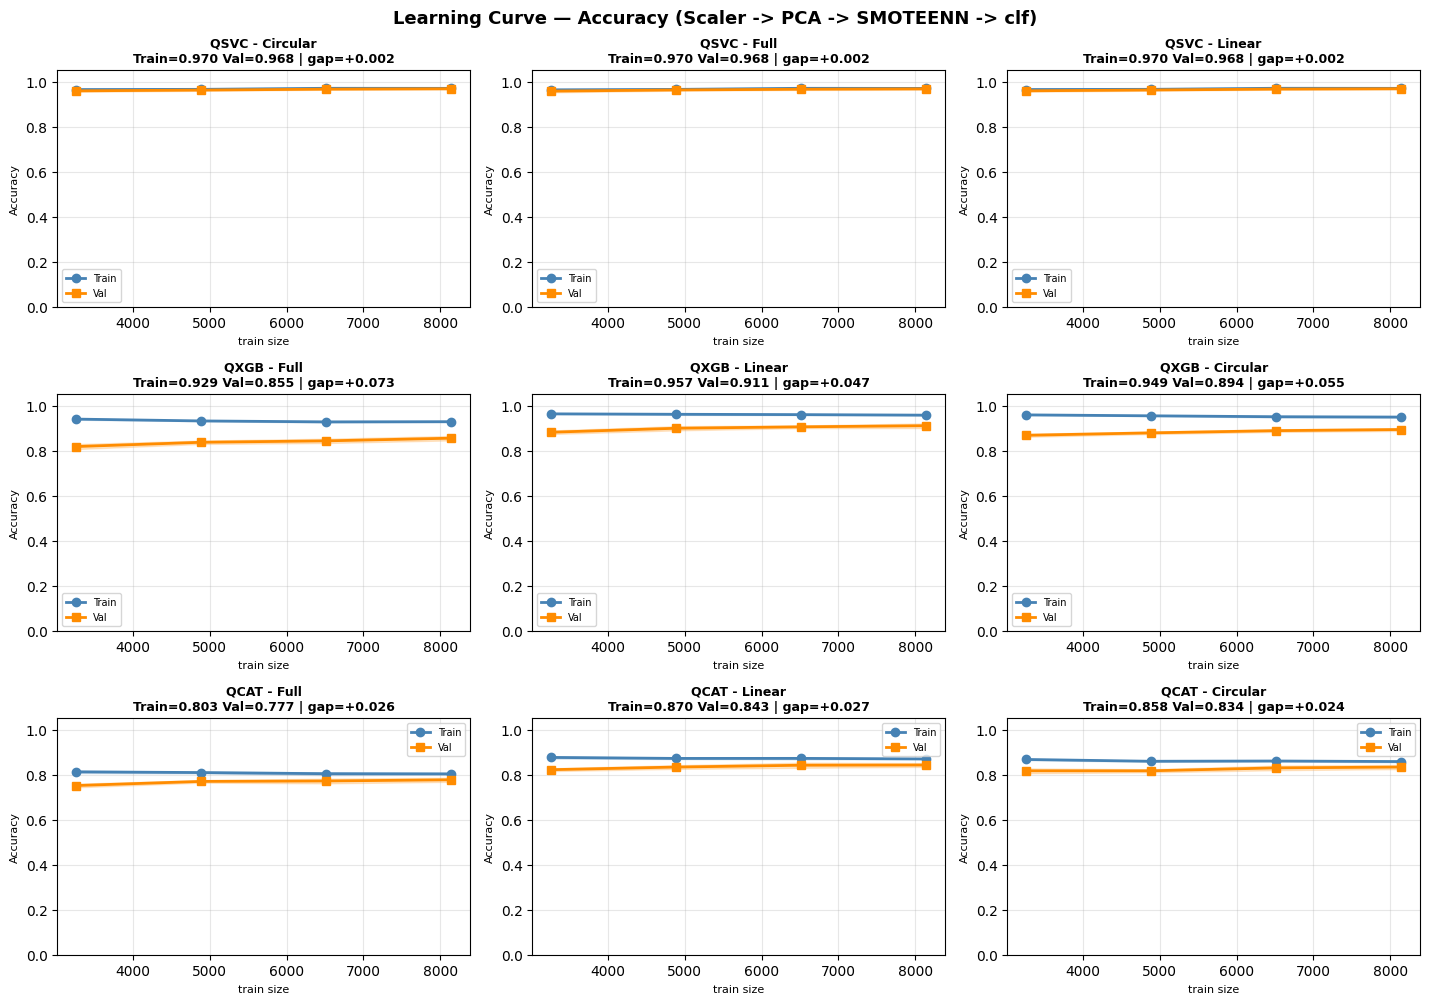

📊 Plot disimpan → ./results/images/learning_curve_precision_quantum_hpo.png


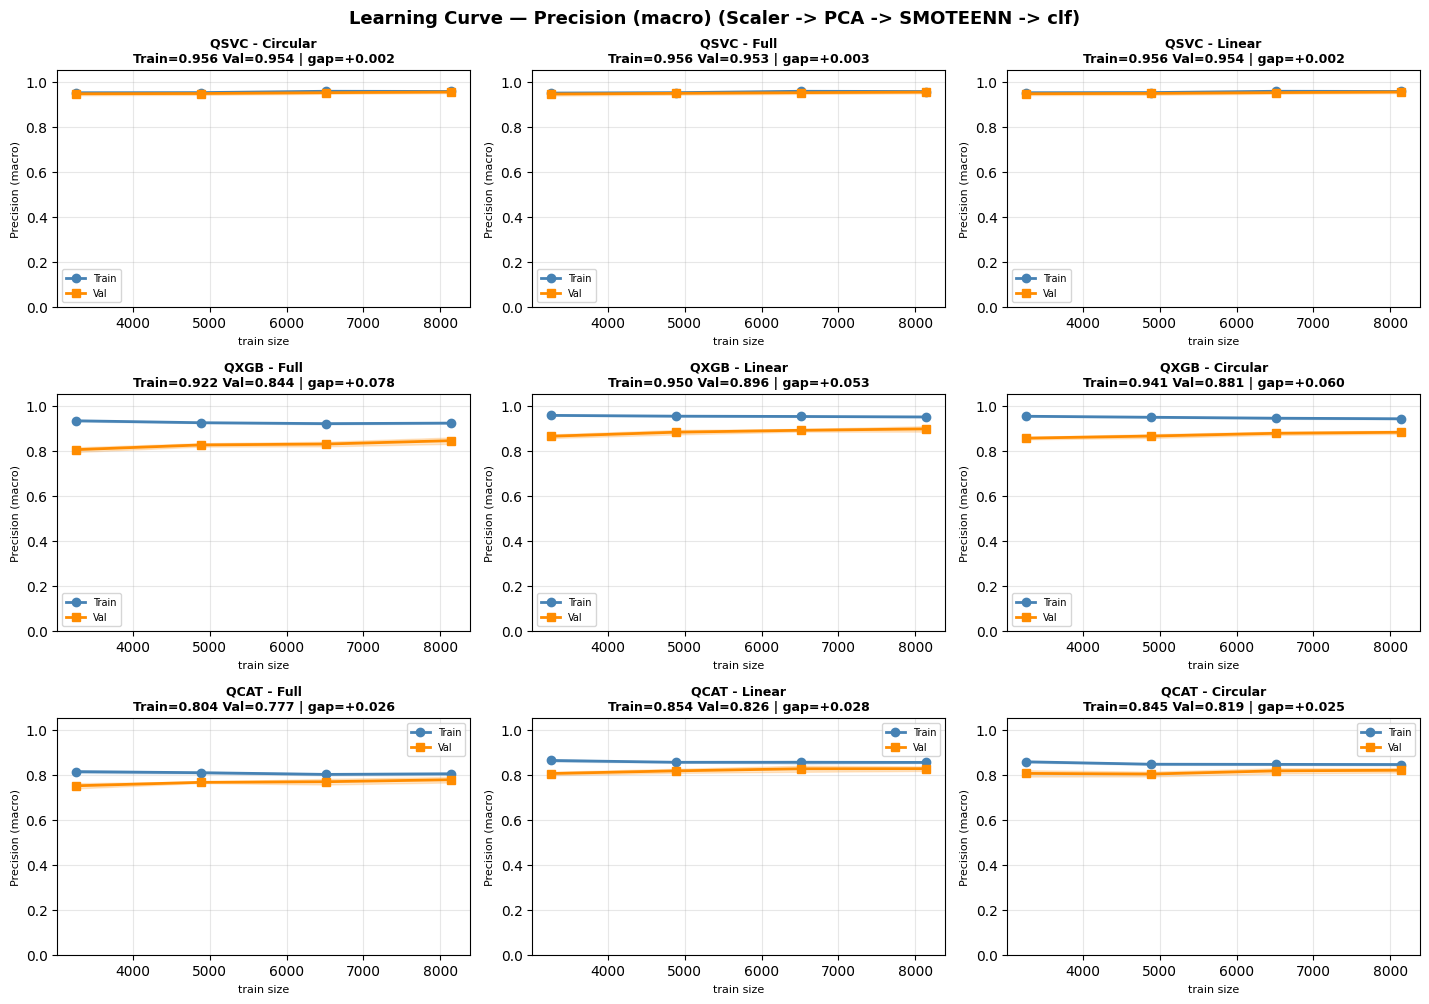

📊 Plot disimpan → ./results/images/learning_curve_recall_quantum_hpo.png


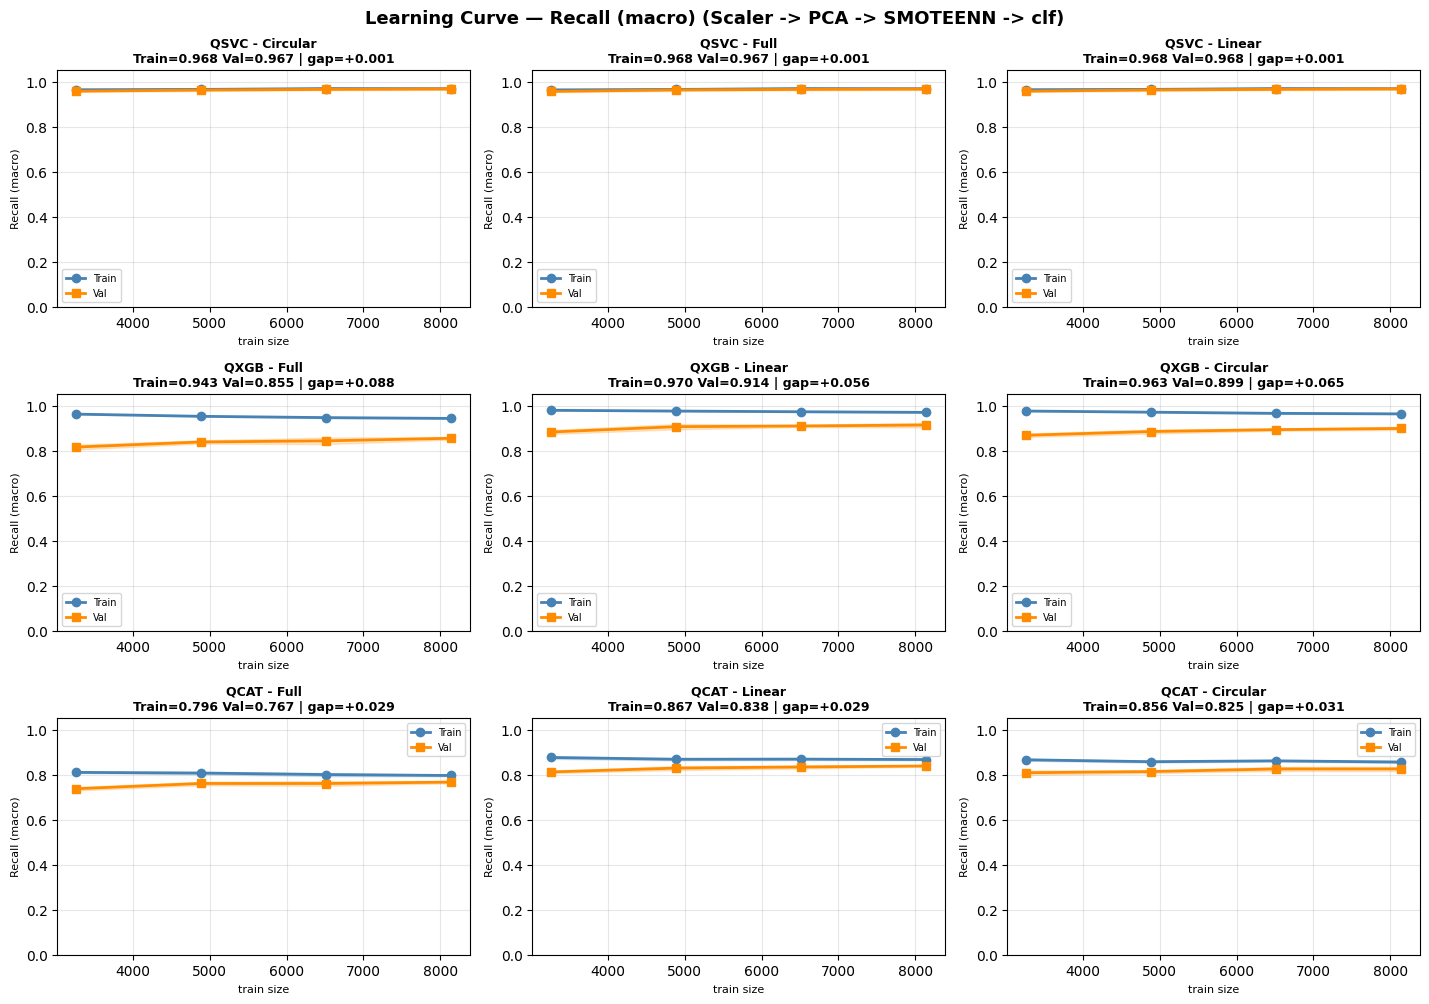

📊 Plot disimpan → ./results/images/learning_curve_f1_quantum_hpo.png


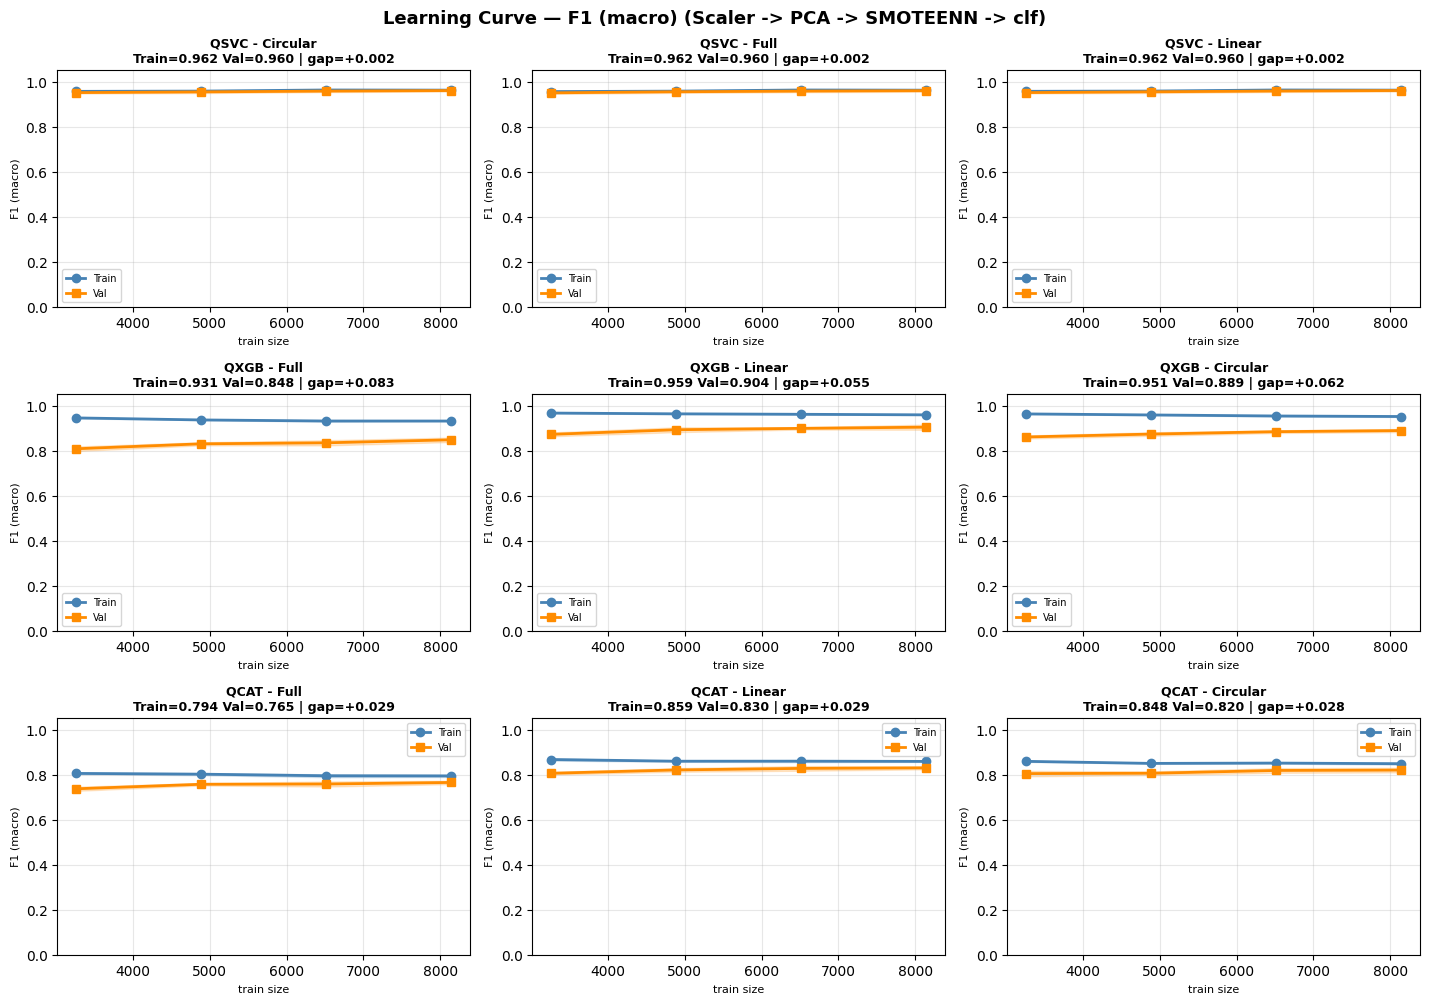

📊 Plot disimpan → ./results/images/learning_curve_log_loss_quantum_hpo.png


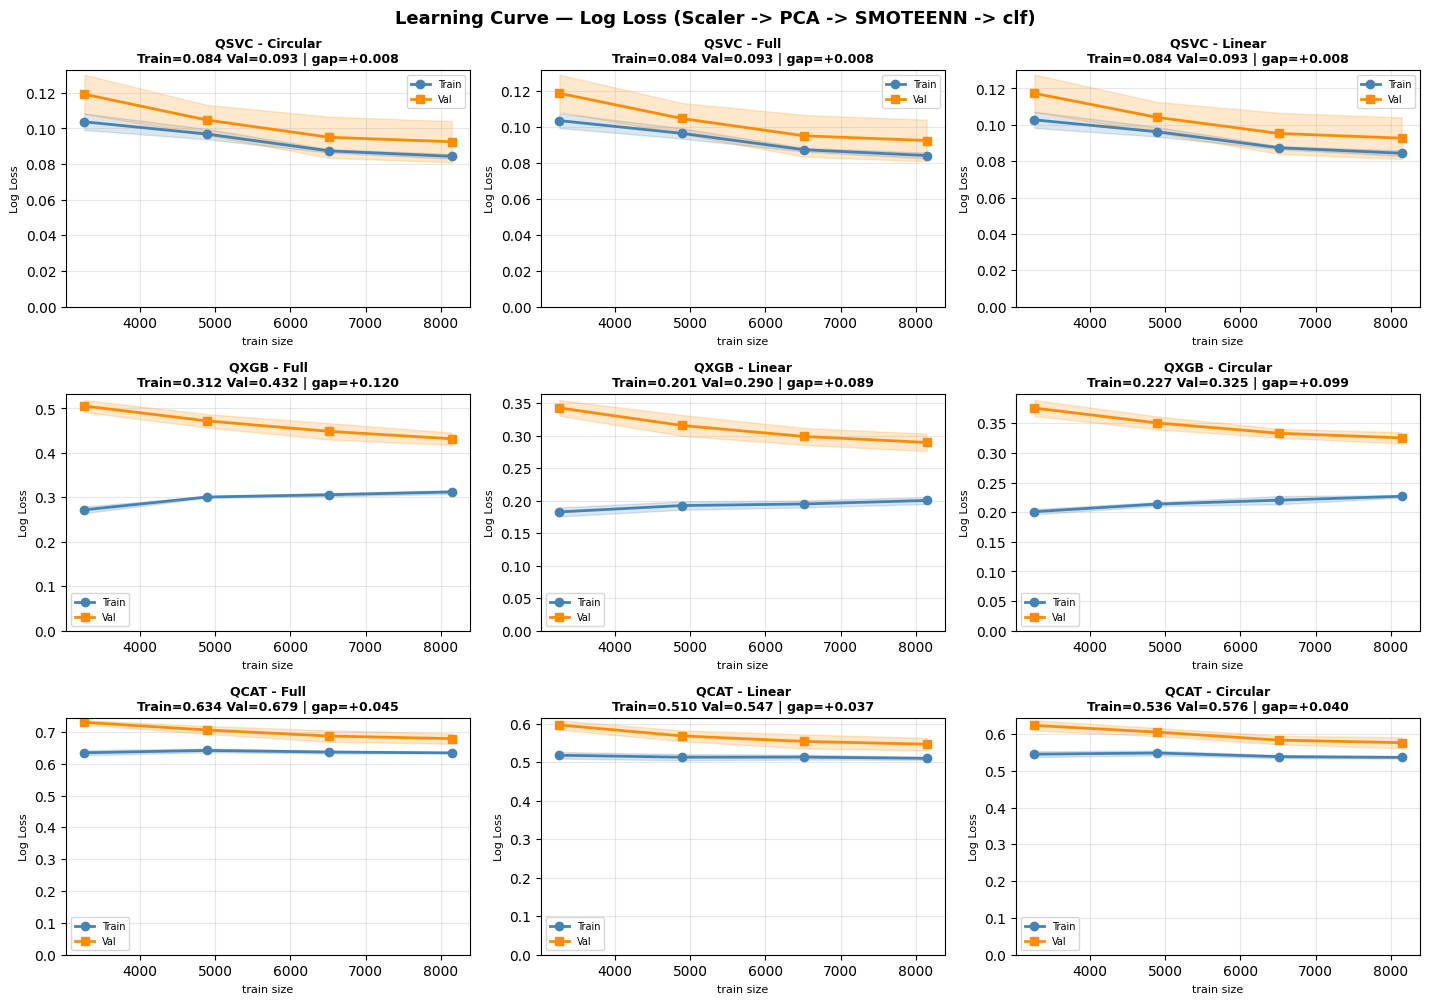

In [53]:
# ════════════════════════════════════════════════════════════
# 📈 Learning Curve — accuracy, precision, recall, f1, log-loss
# ════════════════════════════════════════════════════════════
# Untuk tiap model best: train vs validation pada beberapa ukuran training set,
# memakai pipeline yang SAMA dengan training (Scaler → PCA → SMOTEENN → clf).
# Resampling hanya di subset training tiap fold (no leak); metrik "train" dihitung
# pada subset training ASLI (sebelum resample) supaya gap-nya jujur.
#
# CATATAN PERFORMA (KUANTUM):
#   - LC_N = len(X) (full). Model kuantum jauh lebih lambat: tiap fit menghitung
#     ulang kernel kuantum. Turunkan LC_N untuk subsample stratified bila perlu cepat.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, log_loss,
)

# ── Konfigurasi ───────────────────────────────────────────────────────────────
LC_N           = len(X)                      # subsample stratified (kecilkan utk cepat)
LC_TRAIN_SIZES = np.linspace(0.4, 1.0, 4)    # 5 titik kurva
LC_CV          = 5                           # CV folds (sama dgn training)
LC_STATE       = 42
_classes       = np.unique(y)

# metric_name -> (fn(y_true, y_pred, y_prob) -> nilai, lower_is_better)
def _m_acc(yt, yp, pp): return accuracy_score(yt, yp)
def _m_prec(yt, yp, pp): return precision_score(yt, yp, average="macro", zero_division=0)
def _m_rec(yt, yp, pp): return recall_score(yt, yp, average="macro", zero_division=0)
def _m_f1(yt, yp, pp): return f1_score(yt, yp, average="macro", zero_division=0)
def _m_loss(yt, yp, pp): return log_loss(yt, pp, labels=_classes)
METRICS = {
    "accuracy":  (_m_acc,  False),
    "precision": (_m_prec, False),
    "recall":    (_m_rec,  False),
    "f1":        (_m_f1,   False),
    "log_loss":  (_m_loss, True),    # ↓ lebih kecil lebih baik
}

# ── Stratified subsample untuk speed ──────────────────────────────────────────
if LC_N < len(X):
    sss = StratifiedShuffleSplit(n_splits=1, train_size=LC_N, random_state=LC_STATE)
    sub_idx, _ = next(sss.split(X, y))
    X_lc, y_lc = X.iloc[sub_idx], y[sub_idx]
else:
    X_lc, y_lc = X, y
print(f"📊 Learning curve on N={len(X_lc)} | CV={LC_CV} | sizes={LC_TRAIN_SIZES}")


def learning_curve_multi(pipe, Xd, yd, train_sizes, cv, state):
    """Satu fit per (fold, size); hitung SEMUA metrik sekaligus.
    Train diukur pada subset training ASLI (pre-resample); val pada fold validasi.
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=state)
    out = {m: {"train": [[] for _ in train_sizes], "val": [[] for _ in train_sizes]}
           for m in METRICS}
    sizes_abs = [[] for _ in train_sizes]
    for tr_idx, va_idx in skf.split(Xd, yd):
        Xtr_f, ytr_f = Xd.iloc[tr_idx], yd[tr_idx]
        Xva, yva = Xd.iloc[va_idx], yd[va_idx]
        for si, ts in enumerate(train_sizes):
            n = int(round(ts * len(tr_idx)))
            if n >= len(tr_idx):
                Xs, ys = Xtr_f, ytr_f
            else:
                sub, _ = next(StratifiedShuffleSplit(
                    n_splits=1, train_size=n, random_state=state).split(Xtr_f, ytr_f))
                Xs, ys = Xtr_f.iloc[sub], ytr_f[sub]
            sizes_abs[si].append(len(Xs))
            m = clone(pipe)
            m.fit(Xs, ys)
            # train pada subset ASLI (resampler dilewati saat predict)
            ytr_pred, ytr_prob = np.ravel(m.predict(Xs)), m.predict_proba(Xs)
            yva_pred, yva_prob = np.ravel(m.predict(Xva)), m.predict_proba(Xva)
            for name, (fn, _) in METRICS.items():
                out[name]["train"][si].append(fn(ys, ytr_pred, ytr_prob))
                out[name]["val"][si].append(fn(yva, yva_pred, yva_prob))
    sizes_mean = [int(np.mean(s)) for s in sizes_abs]
    agg = {}
    for name in METRICS:
        agg[name] = {
            "train_mean": np.array([np.mean(v) for v in out[name]["train"]]),
            "train_std":  np.array([np.std(v)  for v in out[name]["train"]]),
            "val_mean":   np.array([np.mean(v) for v in out[name]["val"]]),
            "val_std":    np.array([np.std(v)  for v in out[name]["val"]]),
        }
    return sizes_mean, agg


# ── Hitung learning curve per model (checkpoint resume) ───────────────────────
# Hasil tiap model disimpan ke pickle; re-run MELEWATI model yang sudah dihitung
# selama signature (params + konfigurasi LC + resampling) tidak berubah.
# Set LC_FORCE=True untuk mengabaikan checkpoint & menghitung ulang semua.
import os, pickle

LC_CKPT  = f"./results/checkpoints/qml_learning_curve_{config_slug()}.pkl"
LC_FORCE = False
os.makedirs(os.path.dirname(LC_CKPT), exist_ok=True)

def _lc_signature(name, params):
    return {
        "model": name, "params": params,
        "LC_N": int(len(X_lc)), "sizes": [float(s) for s in LC_TRAIN_SIZES],
        "cv": int(LC_CV), "state": int(LC_STATE),
        "drop": list(DROP_CLASSES), "targets": CUSTOM_TARGETS if isinstance(CUSTOM_TARGETS, str) else dict(CUSTOM_TARGETS),
        "over": OVER_METHOD, "under": UNDER_METHOD,
    }

_lc_ckpt = {}
if os.path.exists(LC_CKPT) and not LC_FORCE:
    with open(LC_CKPT, "rb") as _f:
        _lc_ckpt = pickle.load(_f)

lc_results = []
for entry in all_best:
    name   = entry["model"]
    params = entry.get("params", {})
    _sig = _lc_signature(name, params)
    _cached = _lc_ckpt.get(name)
    if not LC_FORCE and _cached is not None and _cached.get("sig") == _sig:
        print(f"  ⏭️  {name} (cached)")
        lc_results.append(_cached["entry"])
        continue
    print(f"  ▶ {name}  ({params}) ...", end=" ", flush=True)
    try:
        pipe = make_quantum(name, params)
        sizes_mean, agg = learning_curve_multi(pipe, X_lc, y_lc,
                                               LC_TRAIN_SIZES, LC_CV, LC_STATE)
        _ent = {"model": name, "sizes": sizes_mean, "agg": agg}
        lc_results.append(_ent)
        _lc_ckpt[name] = {"sig": _sig, "entry": _ent}
        with open(LC_CKPT, "wb") as _f:
            pickle.dump(_lc_ckpt, _f)
        print("done (checkpoint saved)")
    except Exception as e:
        print(f"FAILED — {type(e).__name__}: {e}")

# ── Plot: SATU figure per metrik (subplot = tiap model) ──────────────────────
metric_names = list(METRICS.keys())
TITLES = {"accuracy": "Accuracy", "precision": "Precision (macro)",
          "recall": "Recall (macro)", "f1": "F1 (macro)", "log_loss": "Log Loss"}
os.makedirs("./results/images", exist_ok=True)
os.makedirs("./results/csv", exist_ok=True)

n_models = len(lc_results)
ncols = min(3, n_models) if n_models else 1
nrows = int(np.ceil(n_models / ncols)) if n_models else 1

for mname in metric_names:
    lower = METRICS[mname][1]
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 3.4 * nrows),
                             squeeze=False)
    axes = axes.ravel()
    for ax, r in zip(axes, lc_results):
        ts = r["sizes"]; a = r["agg"][mname]
        ax.plot(ts, a["train_mean"], "o-", color="steelblue", lw=2, label="Train")
        ax.fill_between(ts, a["train_mean"] - a["train_std"], a["train_mean"] + a["train_std"],
                        alpha=0.2, color="steelblue")
        ax.plot(ts, a["val_mean"], "s-", color="darkorange", lw=2, label="Val")
        ax.fill_between(ts, a["val_mean"] - a["val_std"], a["val_mean"] + a["val_std"],
                        alpha=0.2, color="darkorange")
        gap = (a["val_mean"][-1] - a["train_mean"][-1]) if lower else (a["train_mean"][-1] - a["val_mean"][-1])
        ax.set_title(f"{r['model']}\nTrain={a['train_mean'][-1]:.3f} Val={a['val_mean'][-1]:.3f} | gap={gap:+.3f}",
                     fontsize=9, fontweight="bold")
        ax.set_xlabel("train size", fontsize=8); ax.set_ylabel(TITLES[mname], fontsize=8)
        ax.grid(True, alpha=0.3)
        if lower:
            ax.set_ylim(bottom=0)
        else:
            ax.set_ylim(0, 1.05)
        ax.legend(fontsize=7)
    for ax in axes[n_models:]:
        ax.axis("off")
    fig.suptitle(f"Learning Curve — {TITLES[mname]} (Scaler -> PCA -> SMOTEENN -> clf)",
                 fontsize=13, fontweight="bold")
    fig.tight_layout()
    fig.savefig(f"./results/images/learning_curve_{mname}_quantum_hpo.png", dpi=120, bbox_inches="tight")
    print(f"📊 Plot disimpan → ./results/images/learning_curve_{mname}_quantum_hpo.png")
    plt.show()


### 3.5 Selisih (gap) Train vs Val — tabel terpisah per metrik

Satu tabel untuk tiap metrik berisi `Train` (mean ± std), `Val` (mean ± std), `Selisih (Train-Val)`, dan `overfit_gap`. Konvensi `overfit_gap`: **> 0 = indikasi overfit** (skor = Train − Val; `log_loss` = Val − Train, karena loss makin kecil makin baik). Diukur pada fraksi data latih terbesar. Makin besar `overfit_gap`, makin lebar jurang train ↔ val.

In [54]:
# ════════════════════════════════════════════════════════════
# 📋 Gap Train vs Val per metrik (fraksi data latih terbesar)
# ════════════════════════════════════════════════════════════
metric_names = list(METRICS.keys())
TITLES = {"accuracy": "Accuracy", "precision": "Precision (macro)",
          "recall": "Recall (macro)", "f1": "F1 (macro)", "log_loss": "Log Loss"}

gap_tables = {}
for mname in metric_names:
    lower = METRICS[mname][1]
    rows = []
    for r in lc_results:
        a = r["agg"][mname]
        train_m, train_s = float(a["train_mean"][-1]), float(a["train_std"][-1])
        val_m, val_s = float(a["val_mean"][-1]), float(a["val_std"][-1])
        selisih = train_m - val_m
        overfit_gap = (val_m - train_m) if lower else (train_m - val_m)
        rows.append({"Model": r["model"],
                     "Train": train_m, "Train_std": train_s,
                     "Val": val_m, "Val_std": val_s,
                     "Selisih (Train-Val)": selisih, "overfit_gap": overfit_gap})
    df = pd.DataFrame(rows)
    gap_tables[mname] = df
    df.to_csv(f"./results/csv/learning_curve_gap_{mname}_hpo.csv", index=False)

# Tampilkan satu tabel per metrik (overfit_gap diwarnai; makin merah makin overfit).
for mname in metric_names:
    df = gap_tables[mname]
    disp = pd.DataFrame({"Model": df["Model"]})
    disp["Train"] = [f"{m:.4f} ± {s:.4f}" for m, s in zip(df["Train"], df["Train_std"])]
    disp["Val"]   = [f"{m:.4f} ± {s:.4f}" for m, s in zip(df["Val"], df["Val_std"])]
    disp["Selisih (Train-Val)"] = df["Selisih (Train-Val)"]
    disp["overfit_gap"] = df["overfit_gap"]
    print("=" * 60)
    print(f"Metrik: {TITLES[mname]}")
    display(disp.style.format({"Selisih (Train-Val)": "{:.4f}", "overfit_gap": "{:.4f}"})
            .background_gradient(cmap="Reds", subset=["overfit_gap"]))
print("✅ Saved: ./results/csv/learning_curve_gap_*_hpo.csv")


Metrik: Accuracy


,Model,Train,Val,Selisih (Train-Val),overfit_gap
0,QSVC - Circular,0.9699 ± 0.0005,0.9682 ± 0.0036,0.0017,0.0017
1,QSVC - Full,0.9697 ± 0.0005,0.9678 ± 0.0042,0.0019,0.0019
2,QSVC - Linear,0.9699 ± 0.0005,0.9683 ± 0.0038,0.0017,0.0017
3,QXGB - Full,0.9285 ± 0.0020,0.8552 ± 0.0098,0.0733,0.0733
4,QXGB - Linear,0.9575 ± 0.0011,0.9106 ± 0.0104,0.0469,0.0469
5,QXGB - Circular,0.9490 ± 0.0027,0.8937 ± 0.0063,0.0553,0.0553
6,QCAT - Full,0.8033 ± 0.0035,0.7770 ± 0.0091,0.0263,0.0263
7,QCAT - Linear,0.8697 ± 0.0017,0.8426 ± 0.0084,0.0271,0.0271
8,QCAT - Circular,0.8580 ± 0.0031,0.8336 ± 0.0091,0.0244,0.0244


Metrik: Precision (macro)


,Model,Train,Val,Selisih (Train-Val),overfit_gap
0,QSVC - Circular,0.9562 ± 0.0007,0.9537 ± 0.0049,0.0025,0.0025
1,QSVC - Full,0.9559 ± 0.0008,0.9532 ± 0.0056,0.0026,0.0026
2,QSVC - Linear,0.9561 ± 0.0007,0.9538 ± 0.0050,0.0024,0.0024
3,QXGB - Full,0.9222 ± 0.0024,0.8442 ± 0.0142,0.0780,0.0780
4,QXGB - Linear,0.9495 ± 0.0009,0.8964 ± 0.0122,0.0531,0.0531
5,QXGB - Circular,0.9414 ± 0.0023,0.8815 ± 0.0071,0.0600,0.0600
6,QCAT - Full,0.8036 ± 0.0053,0.7773 ± 0.0122,0.0263,0.0263
7,QCAT - Linear,0.8542 ± 0.0026,0.8264 ± 0.0101,0.0278,0.0278
8,QCAT - Circular,0.8448 ± 0.0038,0.8194 ± 0.0100,0.0254,0.0254


Metrik: Recall (macro)


...

Metrik: F1 (macro)


,Model,Train,Val,Selisih (Train-Val),overfit_gap
0,QSVC - Circular,0.9620 ± 0.0009,0.9602 ± 0.0045,0.0019,0.0019
1,QSVC - Full,0.9619 ± 0.0007,0.9598 ± 0.0050,0.0021,0.0021
2,QSVC - Linear,0.9620 ± 0.0007,0.9604 ± 0.0046,0.0017,0.0017
3,QXGB - Full,0.9314 ± 0.0017,0.8480 ± 0.0100,0.0834,0.0834
4,QXGB - Linear,0.9589 ± 0.0008,0.9041 ± 0.0114,0.0548,0.0548
5,QXGB - Circular,0.9515 ± 0.0019,0.8891 ± 0.0069,0.0624,0.0624
6,QCAT - Full,0.7942 ± 0.0048,0.7652 ± 0.0076,0.0290,0.0290
7,QCAT - Linear,0.8587 ± 0.0022,0.8300 ± 0.0067,0.0287,0.0287
8,QCAT - Circular,0.8485 ± 0.0043,0.8201 ± 0.0103,0.0284,0.0284


Metrik: Log Loss


,Model,Train,Val,Selisih (Train-Val),overfit_gap
0,QSVC - Circular,0.0843 ± 0.0013,0.0925 ± 0.0115,-0.0082,0.0082
1,QSVC - Full,0.0842 ± 0.0016,0.0926 ± 0.0116,-0.0084,0.0084
2,QSVC - Linear,0.0844 ± 0.0015,0.0927 ± 0.0115,-0.0083,0.0083
3,QXGB - Full,0.3121 ± 0.0044,0.4318 ± 0.0140,-0.1197,0.1197
4,QXGB - Linear,0.2005 ± 0.0056,0.2898 ± 0.0134,-0.0893,0.0893
5,QXGB - Circular,0.2268 ± 0.0021,0.3254 ± 0.0095,-0.0985,0.0985
6,QCAT - Full,0.6340 ± 0.0013,0.6787 ± 0.0160,-0.0447,0.0447
7,QCAT - Linear,0.5103 ± 0.0042,0.5470 ± 0.0163,-0.0367,0.0367
8,QCAT - Circular,0.5364 ± 0.0032,0.5764 ± 0.0150,-0.0400,0.0400


✅ Saved: ./results/csv/learning_curve_gap_*_hpo.csv


## Metrik & Kurva Tambahan (Balanced/Weighted, ROC, PR, Normalized CM)

Tambahan evaluasi **tanpa mengubah** sel/grafik existing:

- **Balanced Accuracy** + **Weighted** precision/recall/f1 (pelengkap metrik macro).
- **Kurva ROC** One-vs-Rest (per kelas + micro-average).
- **Kurva Precision-Recall** (per kelas + micro-average).
- **Confusion matrix ter-normalisasi** (baris = recall per kelas).

> Kurva ROC/PR memakai probabilitas OOF (`y_prob`) yang kini disimpan `evaluate_cv`.
> Bila checkpoint lama belum memuat `y_prob`, **rerun** sel-sel training di atas dulu
> (set `RESET_CHECKPOINT = True`) agar `y_prob` ikut tersimpan.

In [55]:
# ════════════════════════════════════════════════════════════
# ➕ Metrik tambahan — Balanced Accuracy + Weighted (Precision/Recall/F1)
# ════════════════════════════════════════════════════════════
# Dihitung dari prediksi OOF (y_true/y_pred) yang sudah tersimpan tiap model —
# TIDAK melatih ulang. Balanced Acc = rata-rata recall per kelas (cocok data
# imbalanced); Weighted = ditimbang support. F1 (macro) ditaruh sebagai pembanding.
import os
import pandas as pd
from sklearn.metrics import (
    balanced_accuracy_score, precision_score, recall_score, f1_score,
)

_rows = []
for r in all_best:
    if "y_true" not in r or "y_pred" not in r:
        continue
    yt, yp = r["y_true"], r["y_pred"]
    _rows.append({
        "Model"        : r["model"],
        "Balanced Acc" : balanced_accuracy_score(yt, yp),
        "Precision (w)": precision_score(yt, yp, average="weighted", zero_division=0),
        "Recall (w)"   : recall_score(yt, yp, average="weighted", zero_division=0),
        "F1 (w)"       : f1_score(yt, yp, average="weighted", zero_division=0),
        "F1 (macro)"   : f1_score(yt, yp, average="macro", zero_division=0),
    })
extra_df = pd.DataFrame(_rows).sort_values("F1 (w)", ascending=False).reset_index(drop=True)
extra_df.index += 1
_fmt = {c: "{:.4f}" for c in extra_df.columns if c != "Model"}
display(extra_df.style.format(_fmt)
        .background_gradient(cmap="Greens",
                             subset=["Balanced Acc", "Precision (w)", "Recall (w)", "F1 (w)"]))

os.makedirs("./results/csv", exist_ok=True)
extra_df.to_csv("./results/csv/eval_extra_metrics_quantum_hpo.csv", index=True)
print("✅ Saved: ./results/csv/eval_extra_metrics_quantum_hpo.csv")

,Model,Balanced Acc,Precision (w),Recall (w),F1 (w),F1 (macro)
1,QSVC - Linear,0.9677,0.9693,0.9683,0.9685,0.9604
2,QSVC - Circular,0.9674,0.9692,0.9682,0.9684,0.9602
3,QSVC - Full,0.9671,0.9688,0.9678,0.9680,0.9598
4,QXGB - Linear,0.9137,0.9136,0.9106,0.9110,0.9041
5,QXGB - Circular,0.8985,0.8965,0.8937,0.8941,0.8891
6,QXGB - Full,0.8548,0.8594,0.8552,0.8558,0.8480
7,QCAT - Linear,0.8384,0.8497,0.8426,0.8437,0.8300
8,QCAT - Circular,0.8252,0.8395,0.8336,0.8342,0.8201
9,QCAT - Full,0.7668,0.7897,0.7770,0.7778,0.7652


✅ Saved: ./results/csv/eval_extra_metrics_quantum_hpo.csv


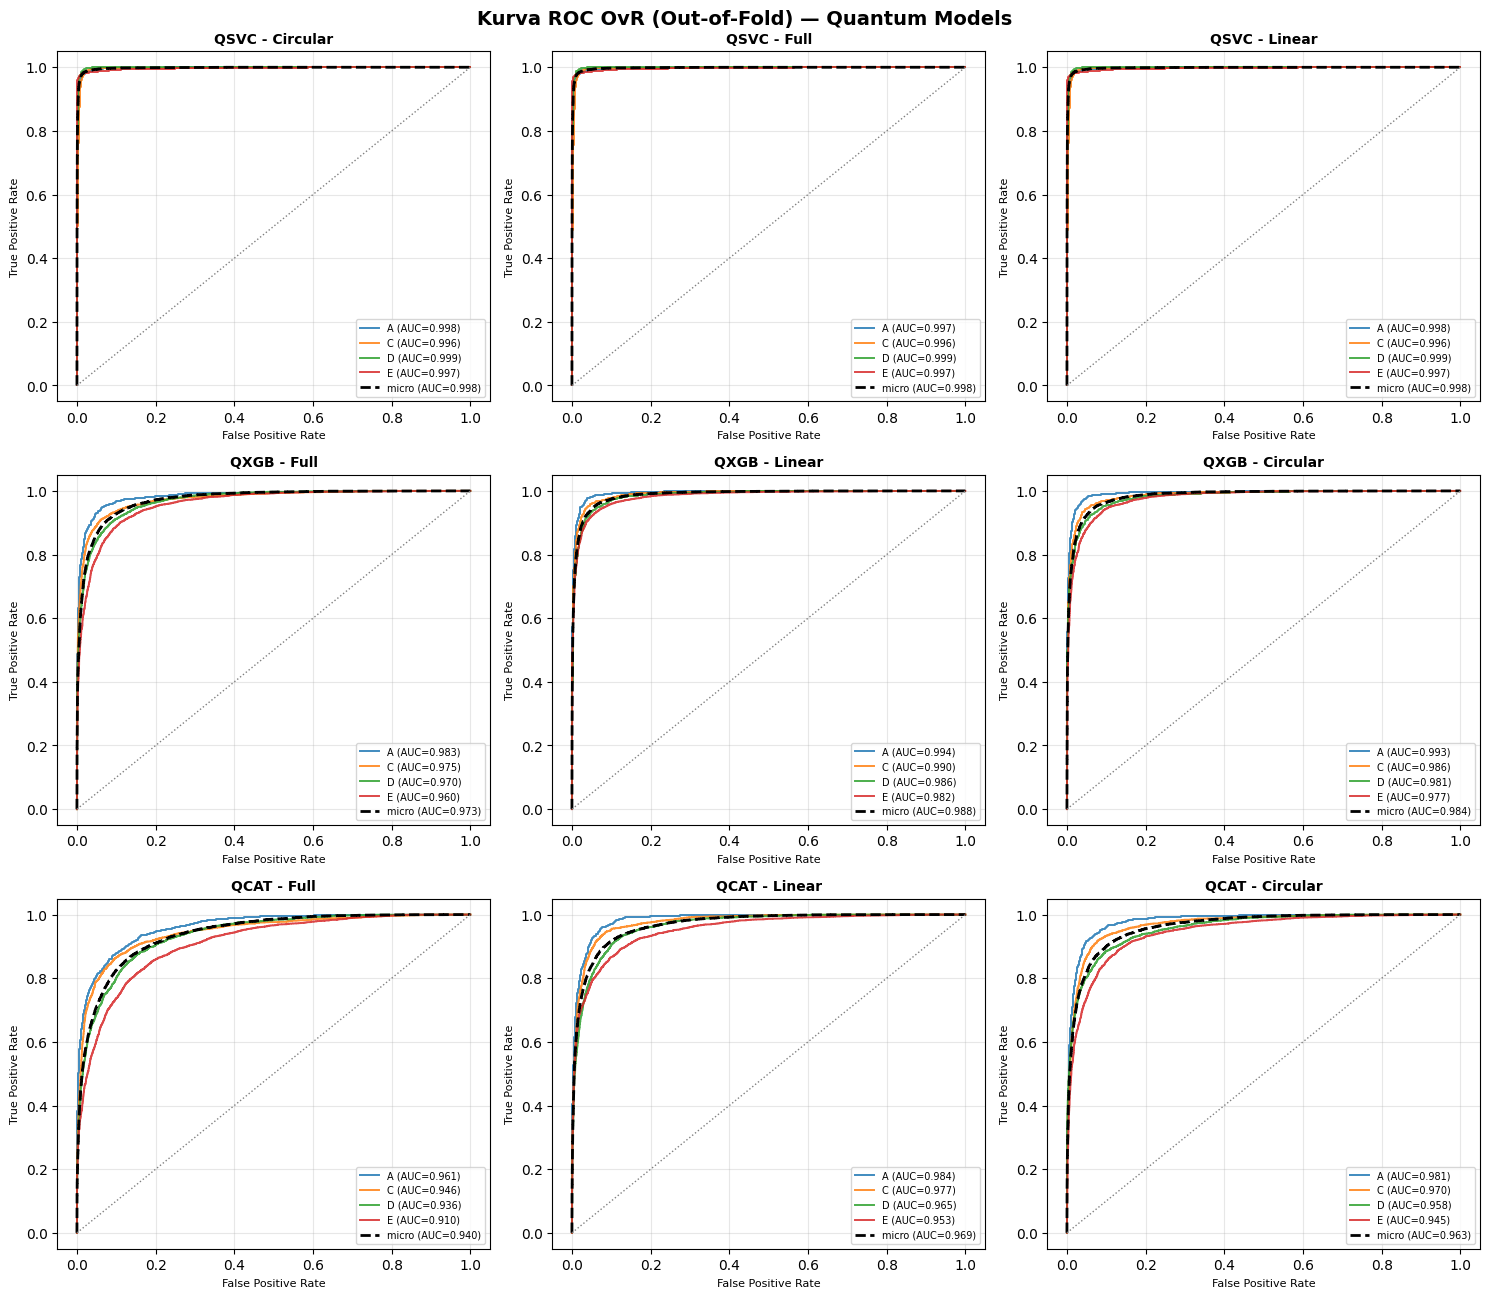

✅ Saved: ./results/images/roc_curve_quantum_hpo.png


In [56]:
# ════════════════════════════════════════════════════════════
# 📈 Kurva ROC One-vs-Rest (OOF) — per kelas + micro-average, tiap model
# ════════════════════════════════════════════════════════════
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

_cls_names = [str(c) for c in label_encoder.classes_]
_classes   = np.unique(y)
models_p = [r for r in all_best if r.get("y_prob") is not None]

if not models_p:
    print("⚠️  Belum ada 'y_prob' di all_best. Rerun sel training (evaluate_cv kini "
          "menyimpan probabilitas OOF; set RESET_CHECKPOINT=True), lalu ulangi sel ini.")
else:
    n = len(models_p); ncols = min(3, n); nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.4 * nrows), squeeze=False)
    axes = axes.ravel()
    for ax, r in zip(axes, models_p):
        yt = np.asarray(r["y_true"])
        Y  = label_binarize(yt, classes=_classes)
        P  = np.asarray(r["y_prob"])
        for i, cn in enumerate(_cls_names):
            fpr, tpr, _ = roc_curve(Y[:, i], P[:, i])
            ax.plot(fpr, tpr, lw=1.4, alpha=0.85, label=f"{cn} (AUC={auc(fpr, tpr):.3f})")
        fpr_mi, tpr_mi, _ = roc_curve(Y.ravel(), P.ravel())
        ax.plot(fpr_mi, tpr_mi, "k--", lw=2, label=f"micro (AUC={auc(fpr_mi, tpr_mi):.3f})")
        ax.plot([0, 1], [0, 1], color="gray", ls=":", lw=1)
        ax.set_title(r["model"], fontsize=10, fontweight="bold")
        ax.set_xlabel("False Positive Rate", fontsize=8)
        ax.set_ylabel("True Positive Rate", fontsize=8)
        ax.legend(fontsize=7, loc="lower right"); ax.grid(alpha=0.3)
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle("Kurva ROC OvR (Out-of-Fold) — Quantum Models", fontsize=14, fontweight="bold")
    fig.tight_layout()
    os.makedirs("./results/images", exist_ok=True)
    out = "./results/images/roc_curve_quantum_hpo.png"
    fig.savefig(out, dpi=140, bbox_inches="tight"); plt.show()
    print(f"✅ Saved: {out}")

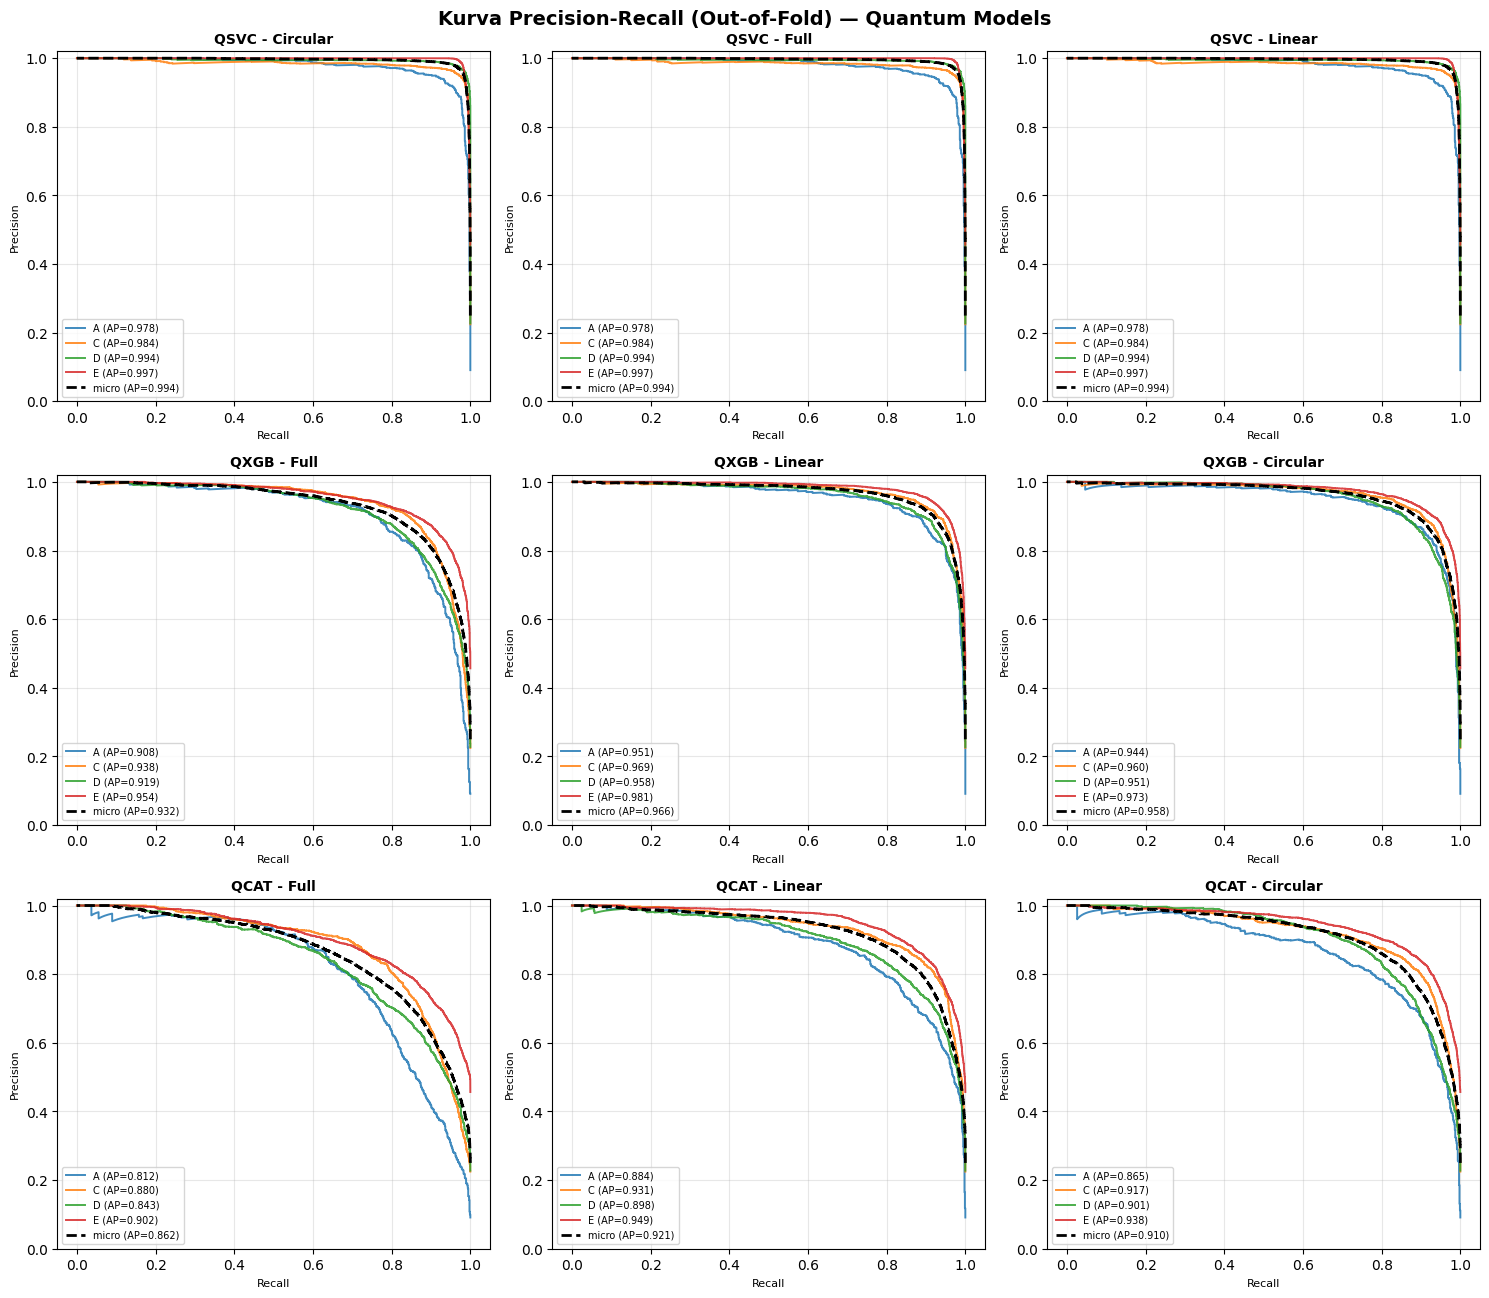

✅ Saved: ./results/images/pr_curve_quantum_hpo.png


In [57]:
# ════════════════════════════════════════════════════════════
# 📈 Kurva Precision-Recall (OOF) — per kelas + micro-average, tiap model
# ════════════════════════════════════════════════════════════
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

_cls_names = [str(c) for c in label_encoder.classes_]
_classes   = np.unique(y)
models_p = [r for r in all_best if r.get("y_prob") is not None]

if not models_p:
    print("⚠️  Belum ada 'y_prob' di all_best. Rerun sel training lalu ulangi sel ini.")
else:
    n = len(models_p); ncols = min(3, n); nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.4 * nrows), squeeze=False)
    axes = axes.ravel()
    for ax, r in zip(axes, models_p):
        yt = np.asarray(r["y_true"])
        Y  = label_binarize(yt, classes=_classes)
        P  = np.asarray(r["y_prob"])
        for i, cn in enumerate(_cls_names):
            prec, rec, _ = precision_recall_curve(Y[:, i], P[:, i])
            ap = average_precision_score(Y[:, i], P[:, i])
            ax.plot(rec, prec, lw=1.4, alpha=0.85, label=f"{cn} (AP={ap:.3f})")
        prec_mi, rec_mi, _ = precision_recall_curve(Y.ravel(), P.ravel())
        ap_mi = average_precision_score(Y, P, average="micro")
        ax.plot(rec_mi, prec_mi, "k--", lw=2, label=f"micro (AP={ap_mi:.3f})")
        ax.set_title(r["model"], fontsize=10, fontweight="bold")
        ax.set_xlabel("Recall", fontsize=8); ax.set_ylabel("Precision", fontsize=8)
        ax.set_ylim(0, 1.02); ax.legend(fontsize=7, loc="lower left"); ax.grid(alpha=0.3)
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle("Kurva Precision-Recall (Out-of-Fold) — Quantum Models", fontsize=14, fontweight="bold")
    fig.tight_layout()
    os.makedirs("./results/images", exist_ok=True)
    out = "./results/images/pr_curve_quantum_hpo.png"
    fig.savefig(out, dpi=140, bbox_inches="tight"); plt.show()
    print(f"✅ Saved: {out}")

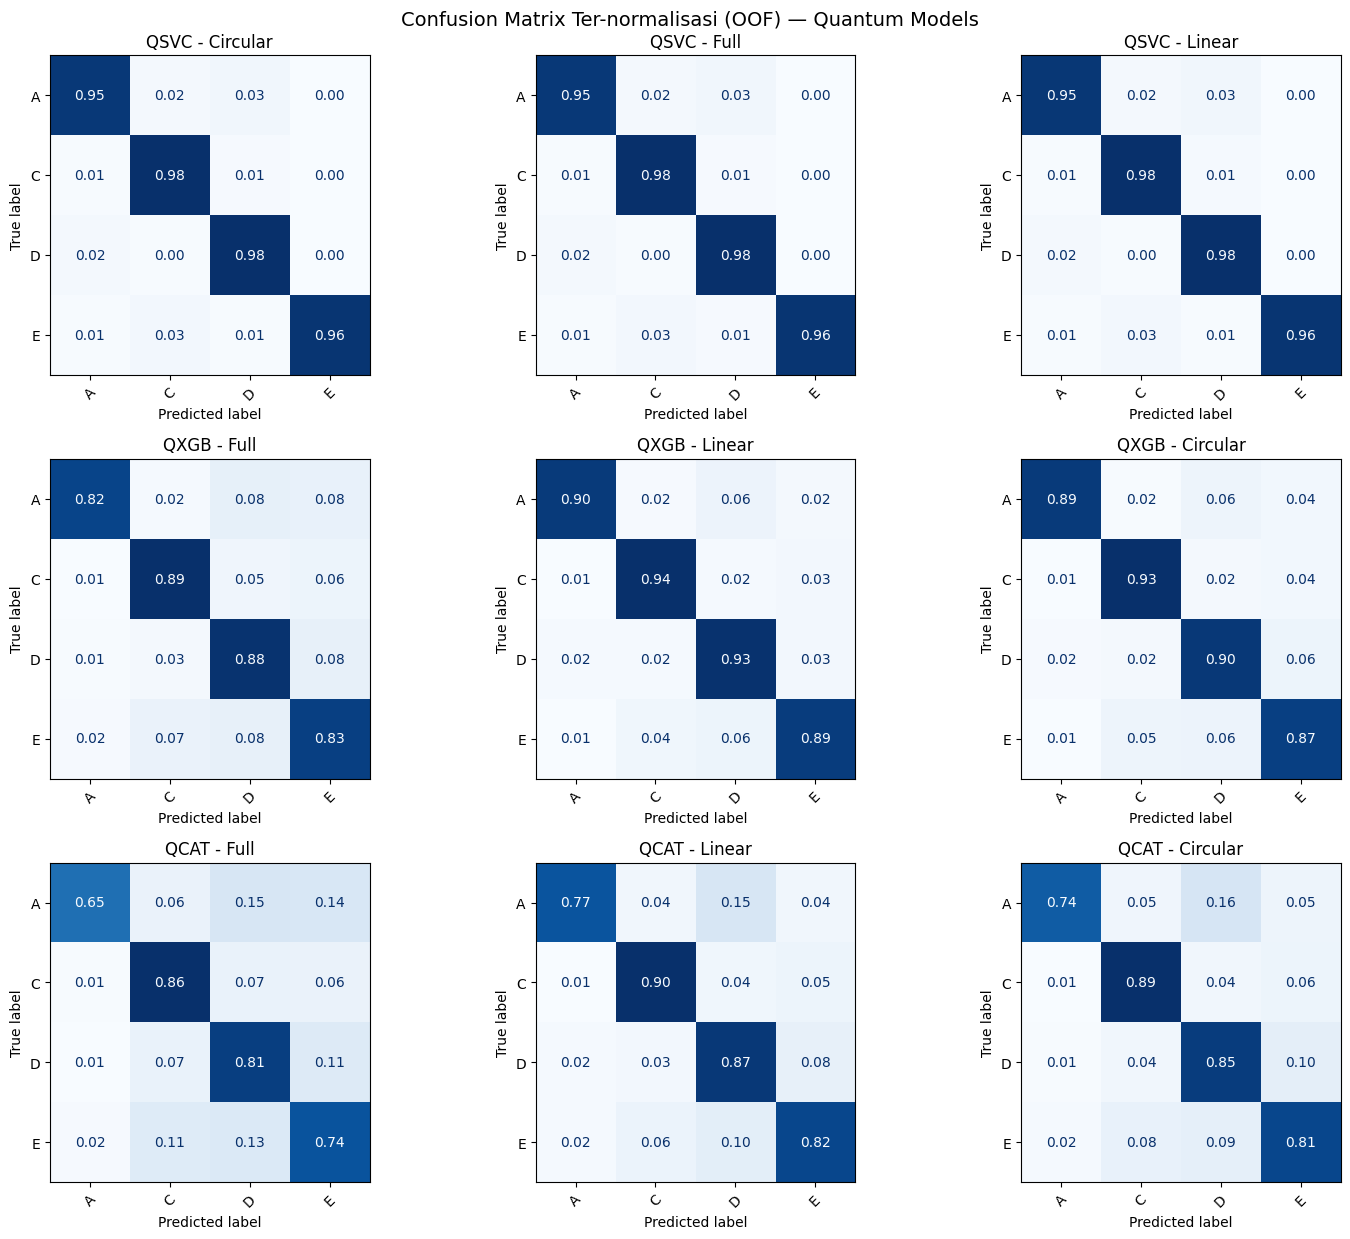

✅ Saved: ./results/images/confusion_matrix_normalized_quantum_hpo.png


In [58]:
# ════════════════════════════════════════════════════════════
# 🔢 Confusion Matrix TER-NORMALISASI (baris = recall per kelas) — OOF
# ════════════════════════════════════════════════════════════
# Versi normalisasi (normalize='true') dari confusion matrix existing. Tiap baris
# jadi proporsi → mudah baca performa per kelas saat support antar-kelas timpang.
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

_cls_names = list(label_encoder.classes_)
_labels = np.arange(len(_cls_names))
models_cm = [r for r in all_best if "y_true" in r and "y_pred" in r]

if not models_cm:
    print("⚠️  Belum ada y_true/y_pred di all_best.")
else:
    n = len(models_cm); ncols = 3; nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.2 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, r in zip(axes, models_cm):
        cm = confusion_matrix(r["y_true"], r["y_pred"], labels=_labels, normalize="true")
        ConfusionMatrixDisplay(cm, display_labels=_cls_names).plot(
            ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
        ax.set_title(r["model"]); ax.tick_params(axis="x", rotation=45)
    for ax in axes[len(models_cm):]:
        ax.axis("off")
    fig.suptitle("Confusion Matrix Ter-normalisasi (OOF) — Quantum Models", fontsize=14)
    fig.tight_layout()
    os.makedirs("./results/images", exist_ok=True)
    out = "./results/images/confusion_matrix_normalized_quantum_hpo.png"
    fig.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print(f"✅ Saved: {out}")